# EngiOpt Generative Models Debugger

This notebook downloads trained generative models from the EngiOpt WandB project and uses them for design generation and debugging.

**Workflow:**
1. Configure WandB project, model type, problem, and seed — artifacts are downloaded and cached automatically
2. Load the problem and sample test conditions
3. Load the model from the downloaded checkpoint
4. Generate and visualize designs

**Supported Models:**
- `cgan_cnn_2d`: Conditional GAN with CNN architecture
- `gan_cnn_2d`: Unconditional GAN with CNN architecture
- `vqgan`: Vector-Quantized GAN with Transformer (conditional)
- `diffusion_2d_cond`: Conditional Diffusion Model (UNet-based)

**Supported Problems:**
- `beams2d`
- `heatconduction2d`
- `photonics2d`

In [1]:
from __future__ import annotations

import os
import random

from diffusers import UNet2DConditionModel
from engibench.utils.all_problems import BUILTIN_PROBLEMS
import matplotlib.pyplot as plt
import numpy as np
import torch as th
import wandb

from engiopt.cgan_cnn_2d.cgan_cnn_2d import Generator as CGANGenerator
from engiopt.diffusion_2d_cond.diffusion_2d_cond import beta_schedule, DiffusionSampler
from engiopt.gan_cnn_2d.gan_cnn_2d import Generator as GANGenerator
from engiopt.metrics import _numpy_config, _scalar_obj
from engiopt.transforms import drop_constant, get_scalar_condition_keys, normalize, resize_to
from engiopt.vqgan.vqgan import VQGAN, VQGANTransformer

/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


## Step 1: Configure and Download from WandB

Set the model type, problem, seed, and WandB project below.
Artifacts are downloaded on first use and cached locally by the WandB client.

In [36]:
# ============ CONFIGURATION ============
MODEL_TYPE = "cgan_cnn_2d"   # Options: "cgan_cnn_2d", "gan_cnn_2d", "vqgan", "diffusion_2d_cond"
PROBLEM_ID = "thermoelastic2d"        # Options: "beams2d", "heatconduction2d", "photonics2d", "thermoelastic2d"
SEED = 1                      # Seed used during training
WANDB_PROJECT = "engiopt"
WANDB_ENTITY = "engibench"         # Set to your WandB entity string, or None to use default

# Generation parameters
N_SAMPLES = 100
DEVICE = "cuda" if th.cuda.is_available() else ("mps" if th.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ============ DOWNLOAD ARTIFACTS FROM WANDB ============
api = wandb.Api()

def _artifact_path(name: str) -> str:
    prefix = f"{WANDB_ENTITY}/{WANDB_PROJECT}" if WANDB_ENTITY else WANDB_PROJECT
    return f"{prefix}/{name}"

if MODEL_TYPE == "cgan_cnn_2d":
    artifact = api.artifact(_artifact_path(f"{PROBLEM_ID}_cgan_cnn_2d_generator:seed_{SEED}"), type="model")
    run = artifact.logged_by()
    run_config = dict(run.config)
    checkpoint_paths = {"generator": os.path.join(artifact.download(), "generator.pth")}

elif MODEL_TYPE == "gan_cnn_2d":
    artifact = api.artifact(_artifact_path(f"{PROBLEM_ID}_gan_cnn_2d_generator:seed_{SEED}"), type="model")
    run = artifact.logged_by()
    run_config = dict(run.config)
    checkpoint_paths = {"generator": os.path.join(artifact.download(), "generator.pth")}

elif MODEL_TYPE == "vqgan":
    artifact_cvqgan     = api.artifact(_artifact_path(f"{PROBLEM_ID}_vqgan_cvqgan:seed_{SEED}"), type="model")
    artifact_vqgan      = api.artifact(_artifact_path(f"{PROBLEM_ID}_vqgan_vqgan:seed_{SEED}"), type="model")
    artifact_transformer = api.artifact(_artifact_path(f"{PROBLEM_ID}_vqgan_transformer:seed_{SEED}"), type="model")
    run = artifact_transformer.logged_by()
    run_config = dict(run.config)
    checkpoint_paths = {
        "cvqgan":      os.path.join(artifact_cvqgan.download(), "cvqgan.pth"),
        "vqgan":       os.path.join(artifact_vqgan.download(), "vqgan.pth"),
        "transformer": os.path.join(artifact_transformer.download(), "transformer.pth"),
    }

elif MODEL_TYPE == "diffusion_2d_cond":
    artifact = api.artifact(_artifact_path(f"{PROBLEM_ID}_diffusion_2d_cond_model:seed_{SEED}"), type="model")
    run = artifact.logged_by()
    run_config = dict(run.config)
    checkpoint_paths = {"model": os.path.join(artifact.download(), "model.pth")}

else:
    raise ValueError(f"Unknown model type: {MODEL_TYPE!r}")

print(f"\nModel: {MODEL_TYPE} | Problem: {PROBLEM_ID} | Seed: {SEED}")
print("\nRun config:")
for key, value in run_config.items():
    print(f"  {key}: {value}")

Using device: mps


wandb:   1 of 1 files downloaded.  



Model: cgan_cnn_2d | Problem: thermoelastic2d | Seed: 1

Run config:
  b1: 0.5
  b2: 0.999
  algo: cgan_cnn_2d
  seed: 1
  n_cpu: 8
  track: True
  lr_gen: 0.0001
  lr_disc: 0.0004
  n_epochs: 200
  batch_size: 32
  latent_dim: 32
  problem_id: thermoelastic2d
  save_model: True
  wandb_entity: None
  wandb_project: engiopt
  sample_interval: 1000


## Load Problem and Setup

In [37]:
# Load problem from EngiBench
problem = BUILTIN_PROBLEMS[PROBLEM_ID]()
problem.reset(seed=SEED)

design_shape = problem.design_space.shape
n_objs = len(problem.objectives_keys)

# Identify scalar conditions (exclude image-based conditions like 65x65 boundary matrices)
scalar_cond_keys = get_scalar_condition_keys(problem, problem.dataset["test"])
n_conds = len(scalar_cond_keys)

print(f"Design shape: {design_shape}")
print(f"Objectives ({n_objs}): {problem.objectives_keys}")
print(f"All condition keys: {problem.conditions_keys}")
print(f"Scalar condition keys ({n_conds}): {scalar_cond_keys}")
if n_objs > 1:
    print(f"Multi-objective problem — will use weighted-sum via _scalar_obj()")

# Set random seeds for reproducibility
th.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Design shape: (64, 64)
Objectives (3): ['structural_compliance', 'thermal_compliance', 'volume_fraction']
All condition keys: ['fixed_elements', 'force_elements_x', 'force_elements_y', 'heatsink_elements', 'volfrac', 'rmin', 'weight']
Scalar condition keys (3): ['volfrac', 'rmin', 'weight']
Multi-objective problem — will use weighted-sum via _scalar_obj()


## Sample Target Conditions

Generate random target conditions for generation.

In [38]:
rng = np.random.default_rng(SEED)

# Extract the conditions
dataset = problem.dataset["test"]
conditions_ds = dataset.select_columns(problem.conditions_keys)

# Sample conditions and test_ds designs at random indices
selected_indices = rng.choice(len(dataset), N_SAMPLES, replace=True)
sampled_conditions = conditions_ds.select(selected_indices)
sampled_designs_np = np.array(dataset["optimal_design"])[selected_indices]

# ---------- Multi-objective helper ----------
# For multi-objective problems (e.g. thermoelastic2d) compute per-sample
# objective weights so we can reduce obj_values to a scalar via _scalar_obj().

def _sample_obj_weights(config: dict) -> np.ndarray | None:
    """Return per-sample objective weight vector, or None for single-objective."""
    if n_objs <= 1:
        return None
    if "weight" not in config:
        return None
    w = float(config["weight"])
    weights = np.zeros(n_objs)
    weights[0] = w
    weights[1] = 1.0 - w
    return weights

# Compute sampled_obj as the scalar performance target for each sample
# (weighted sum for multi-objective, first objective for single-objective)
sampled_obj = np.empty(N_SAMPLES)
for i in range(N_SAMPLES):
    row = dataset[int(selected_indices[i])]
    obj_vals = [float(row[k]) for k in problem.objectives_keys]
    sampled_obj[i] = _scalar_obj(obj_vals, _sample_obj_weights(row))

# Create tensor for scalar conditions only (used by the generator)
conditions_tensor = th.stack(
    [th.as_tensor(sampled_conditions[c][:]).float() for c in scalar_cond_keys], dim=1
).to(DEVICE)  # (N_SAMPLES, n_conds)

conditions_np = conditions_tensor.cpu().numpy().T  # (n_conds, N_SAMPLES)

print(f"conditions_tensor shape: {conditions_tensor.shape}")
print(f"conditions_np shape:     {conditions_np.shape}")
print(f"sampled_obj range:       [{sampled_obj.min():.4e}, {sampled_obj.max():.4e}]")
if n_objs > 1:
    print(f"(sampled_obj is the weighted-sum of {problem.objectives_keys[:2]})")

conditions_tensor shape: torch.Size([100, 3])
conditions_np shape:     (3, 100)
sampled_obj range:       [6.6653e+00, 9.6625e+01]
(sampled_obj is the weighted-sum of ['structural_compliance', 'thermal_compliance'])


## Load Model from WandB Checkpoint

In [39]:
if MODEL_TYPE == "cgan_cnn_2d":
    ckpt = th.load(checkpoint_paths["generator"], map_location=DEVICE, weights_only=False)
    model = CGANGenerator(
        latent_dim=run_config["latent_dim"],
        n_conds=n_conds,
        design_shape=design_shape,
    )
    model.load_state_dict(ckpt["generator"])
    model.eval().to(DEVICE)
    print(f"Loaded CGAN generator (latent_dim={run_config['latent_dim']})")

elif MODEL_TYPE == "gan_cnn_2d":
    ckpt = th.load(checkpoint_paths["generator"], map_location=DEVICE, weights_only=False)
    model = GANGenerator(
        latent_dim=run_config["latent_dim"],
        design_shape=design_shape,
    )
    model.load_state_dict(ckpt["generator"])
    model.eval().to(DEVICE)
    print(f"Loaded GAN generator (latent_dim={run_config['latent_dim']})")

elif MODEL_TYPE == "vqgan":
    ckpt_cvqgan      = th.load(checkpoint_paths["cvqgan"],      map_location=DEVICE, weights_only=False)
    ckpt_vqgan       = th.load(checkpoint_paths["vqgan"],       map_location=DEVICE, weights_only=False)
    ckpt_transformer = th.load(checkpoint_paths["transformer"], map_location=DEVICE, weights_only=False)

    vqgan = VQGAN(
        device=DEVICE,
        is_c=False,
        encoder_channels=run_config["encoder_channels"],
        encoder_start_resolution=run_config["image_size"],
        encoder_attn_resolutions=run_config["encoder_attn_resolutions"],
        encoder_num_res_blocks=run_config["encoder_num_res_blocks"],
        decoder_channels=run_config["decoder_channels"],
        decoder_start_resolution=run_config["latent_size"],
        decoder_attn_resolutions=run_config["decoder_attn_resolutions"],
        decoder_num_res_blocks=run_config["decoder_num_res_blocks"],
        image_channels=run_config["image_channels"],
        latent_dim=run_config["latent_dim"],
        num_codebook_vectors=run_config["num_codebook_vectors"],
    )
    vqgan.load_state_dict(ckpt_vqgan["vqgan"])
    vqgan.eval().to(DEVICE)

    cvqgan = VQGAN(
        device=DEVICE,
        is_c=True,
        cond_feature_map_dim=run_config["cond_feature_map_dim"],
        cond_dim=run_config["cond_dim"],
        cond_hidden_dim=run_config["cond_hidden_dim"],
        cond_latent_dim=run_config["cond_latent_dim"],
        cond_codebook_vectors=run_config["cond_codebook_vectors"],
    )
    cvqgan.load_state_dict(ckpt_cvqgan["cvqgan"])
    cvqgan.eval().to(DEVICE)

    model = VQGANTransformer(
        conditional=run_config["conditional"],
        vqgan=vqgan,
        cvqgan=cvqgan,
        image_size=run_config["image_size"],
        decoder_channels=run_config["decoder_channels"],
        cond_feature_map_dim=run_config["cond_feature_map_dim"],
        num_codebook_vectors=run_config["num_codebook_vectors"],
        n_layer=run_config["n_layer"],
        n_head=run_config["n_head"],
        n_embd=run_config["n_embd"],
        dropout=run_config["dropout"],
    )
    model.load_state_dict(ckpt_transformer["transformer"])
    model.eval().to(DEVICE)
    print("Loaded VQGAN + CVQGAN + Transformer")

elif MODEL_TYPE == "diffusion_2d_cond":
    ckpt = th.load(checkpoint_paths["model"], map_location=DEVICE, weights_only=False)
    model = UNet2DConditionModel(
        sample_size=design_shape,
        in_channels=1,
        out_channels=1,
        cross_attention_dim=64,
        block_out_channels=(32, 64, 128, 256),
        down_block_types=("CrossAttnDownBlock2D", "CrossAttnDownBlock2D", "CrossAttnDownBlock2D", "DownBlock2D"),
        up_block_types=("UpBlock2D", "CrossAttnUpBlock2D", "CrossAttnUpBlock2D", "CrossAttnUpBlock2D"),
        layers_per_block=run_config["layers_per_block"],
        transformer_layers_per_block=1,
        encoder_hid_dim=n_conds,
        only_cross_attention=True,
    ).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()

    options = {
        "cosine": run_config["noise_schedule"] == "cosine",
        "exp_biasing": run_config["noise_schedule"] == "exp",
        "exp_bias_factor": 1,
    }
    betas = beta_schedule(t=run_config["num_timesteps"], start=1e-4, end=0.02, scale=1.0, options=options)
    ddm_sampler = DiffusionSampler(run_config["num_timesteps"], betas)
    print(f"Loaded Diffusion UNet (num_timesteps={run_config['num_timesteps']})")

print("\nModel loaded successfully!")

Loaded CGAN generator (latent_dim=32)

Model loaded successfully!


## Generate Designs

Generate designs conditioned on the sampled conditions.

In [40]:
with th.no_grad():
    if MODEL_TYPE == "cgan_cnn_2d":
        z = th.randn((N_SAMPLES, run_config["latent_dim"], 1, 1), device=DEVICE)
        c = conditions_tensor.unsqueeze(-1).unsqueeze(-1)  # (N, n_conds, 1, 1)
        gen_designs = model(z, c)
        gen_designs_np = gen_designs.cpu().numpy().reshape(N_SAMPLES, *design_shape)

    elif MODEL_TYPE == "gan_cnn_2d":
        z = th.randn((N_SAMPLES, run_config["latent_dim"], 1, 1), device=DEVICE)
        gen_designs = model(z)
        gen_designs_np = gen_designs.cpu().numpy().reshape(N_SAMPLES, *design_shape)
        print("Note: gan_cnn_2d is unconditional — sampled conditions are for reference only")

    elif MODEL_TYPE == "vqgan":
        # Apply same condition pre-processing as at training time
        sampled_conditions_vqgan = sampled_conditions.select(range(len(sampled_conditions)))
        active_conditions = sampled_conditions_vqgan.column_names
        if run_config.get("drop_constant_conditions", True):
            sampled_conditions_vqgan, active_conditions = drop_constant(sampled_conditions_vqgan, active_conditions)
        if run_config.get("normalize_conditions", True):
            sampled_conditions_vqgan, _mean, _std = normalize(sampled_conditions_vqgan, active_conditions)
        cond_t = th.stack(
            [th.as_tensor(sampled_conditions_vqgan[c][:]).float() for c in active_conditions], dim=1
        ).to(DEVICE)

        if run_config["conditional"]:
            c = model.encode_to_z(x=cond_t, is_c=True)[1]
        else:
            c = th.ones(N_SAMPLES, 1, dtype=th.int64, device=DEVICE) * model.sos_token

        latent_designs = model.sample(
            x=th.empty(N_SAMPLES, 0, dtype=th.int64, device=DEVICE),
            c=c,
            steps=run_config["latent_size"] ** 2,
        )
        gen_designs = resize_to(model.z_to_image(latent_designs), h=design_shape[0], w=design_shape[1])
        gen_designs_np = gen_designs.cpu().numpy().reshape(N_SAMPLES, *design_shape)

    elif MODEL_TYPE == "diffusion_2d_cond":
        enc_states = conditions_tensor.unsqueeze(1)  # (N, 1, n_conds)
        gen_designs = th.randn((N_SAMPLES, 1, *design_shape), device=DEVICE)
        for i in reversed(range(run_config["num_timesteps"])):
            t = th.full((N_SAMPLES,), i, device=DEVICE, dtype=th.long)
            gen_designs = ddm_sampler.sample_timestep(model, gen_designs, t, enc_states)
            if (run_config["num_timesteps"] - i) % 50 == 0:
                print(f"Denoising step {run_config['num_timesteps'] - i}/{run_config['num_timesteps']}")
        gen_designs_np = gen_designs.squeeze(1).cpu().numpy().reshape(N_SAMPLES, *design_shape)

# Store raw designs BEFORE any clipping (for ablation experiments)
gen_designs_raw = gen_designs_np.copy()

# Clip to valid range [0, 1]
gen_designs_np = np.clip(gen_designs_np, 1e-3, 1.0)
print(f"\nGenerated {N_SAMPLES} designs with shape {gen_designs_np.shape}")
print(f"Raw design range: [{gen_designs_raw.min():.4f}, {gen_designs_raw.max():.4f}]")
print(f"Pixels < 0: {(gen_designs_raw < 0).sum()} / {gen_designs_raw.size} ({100*(gen_designs_raw < 0).mean():.2f}%)")
print(f"Pixels > 1: {(gen_designs_raw > 1).sum()} / {gen_designs_raw.size} ({100*(gen_designs_raw > 1).mean():.2f}%)")


Generated 100 designs with shape (100, 64, 64)
Raw design range: [-0.3133, 1.0000]
Pixels < 0: 16849 / 409600 (4.11%)
Pixels > 1: 0 / 409600 (0.00%)


## Visualize Generated Designs

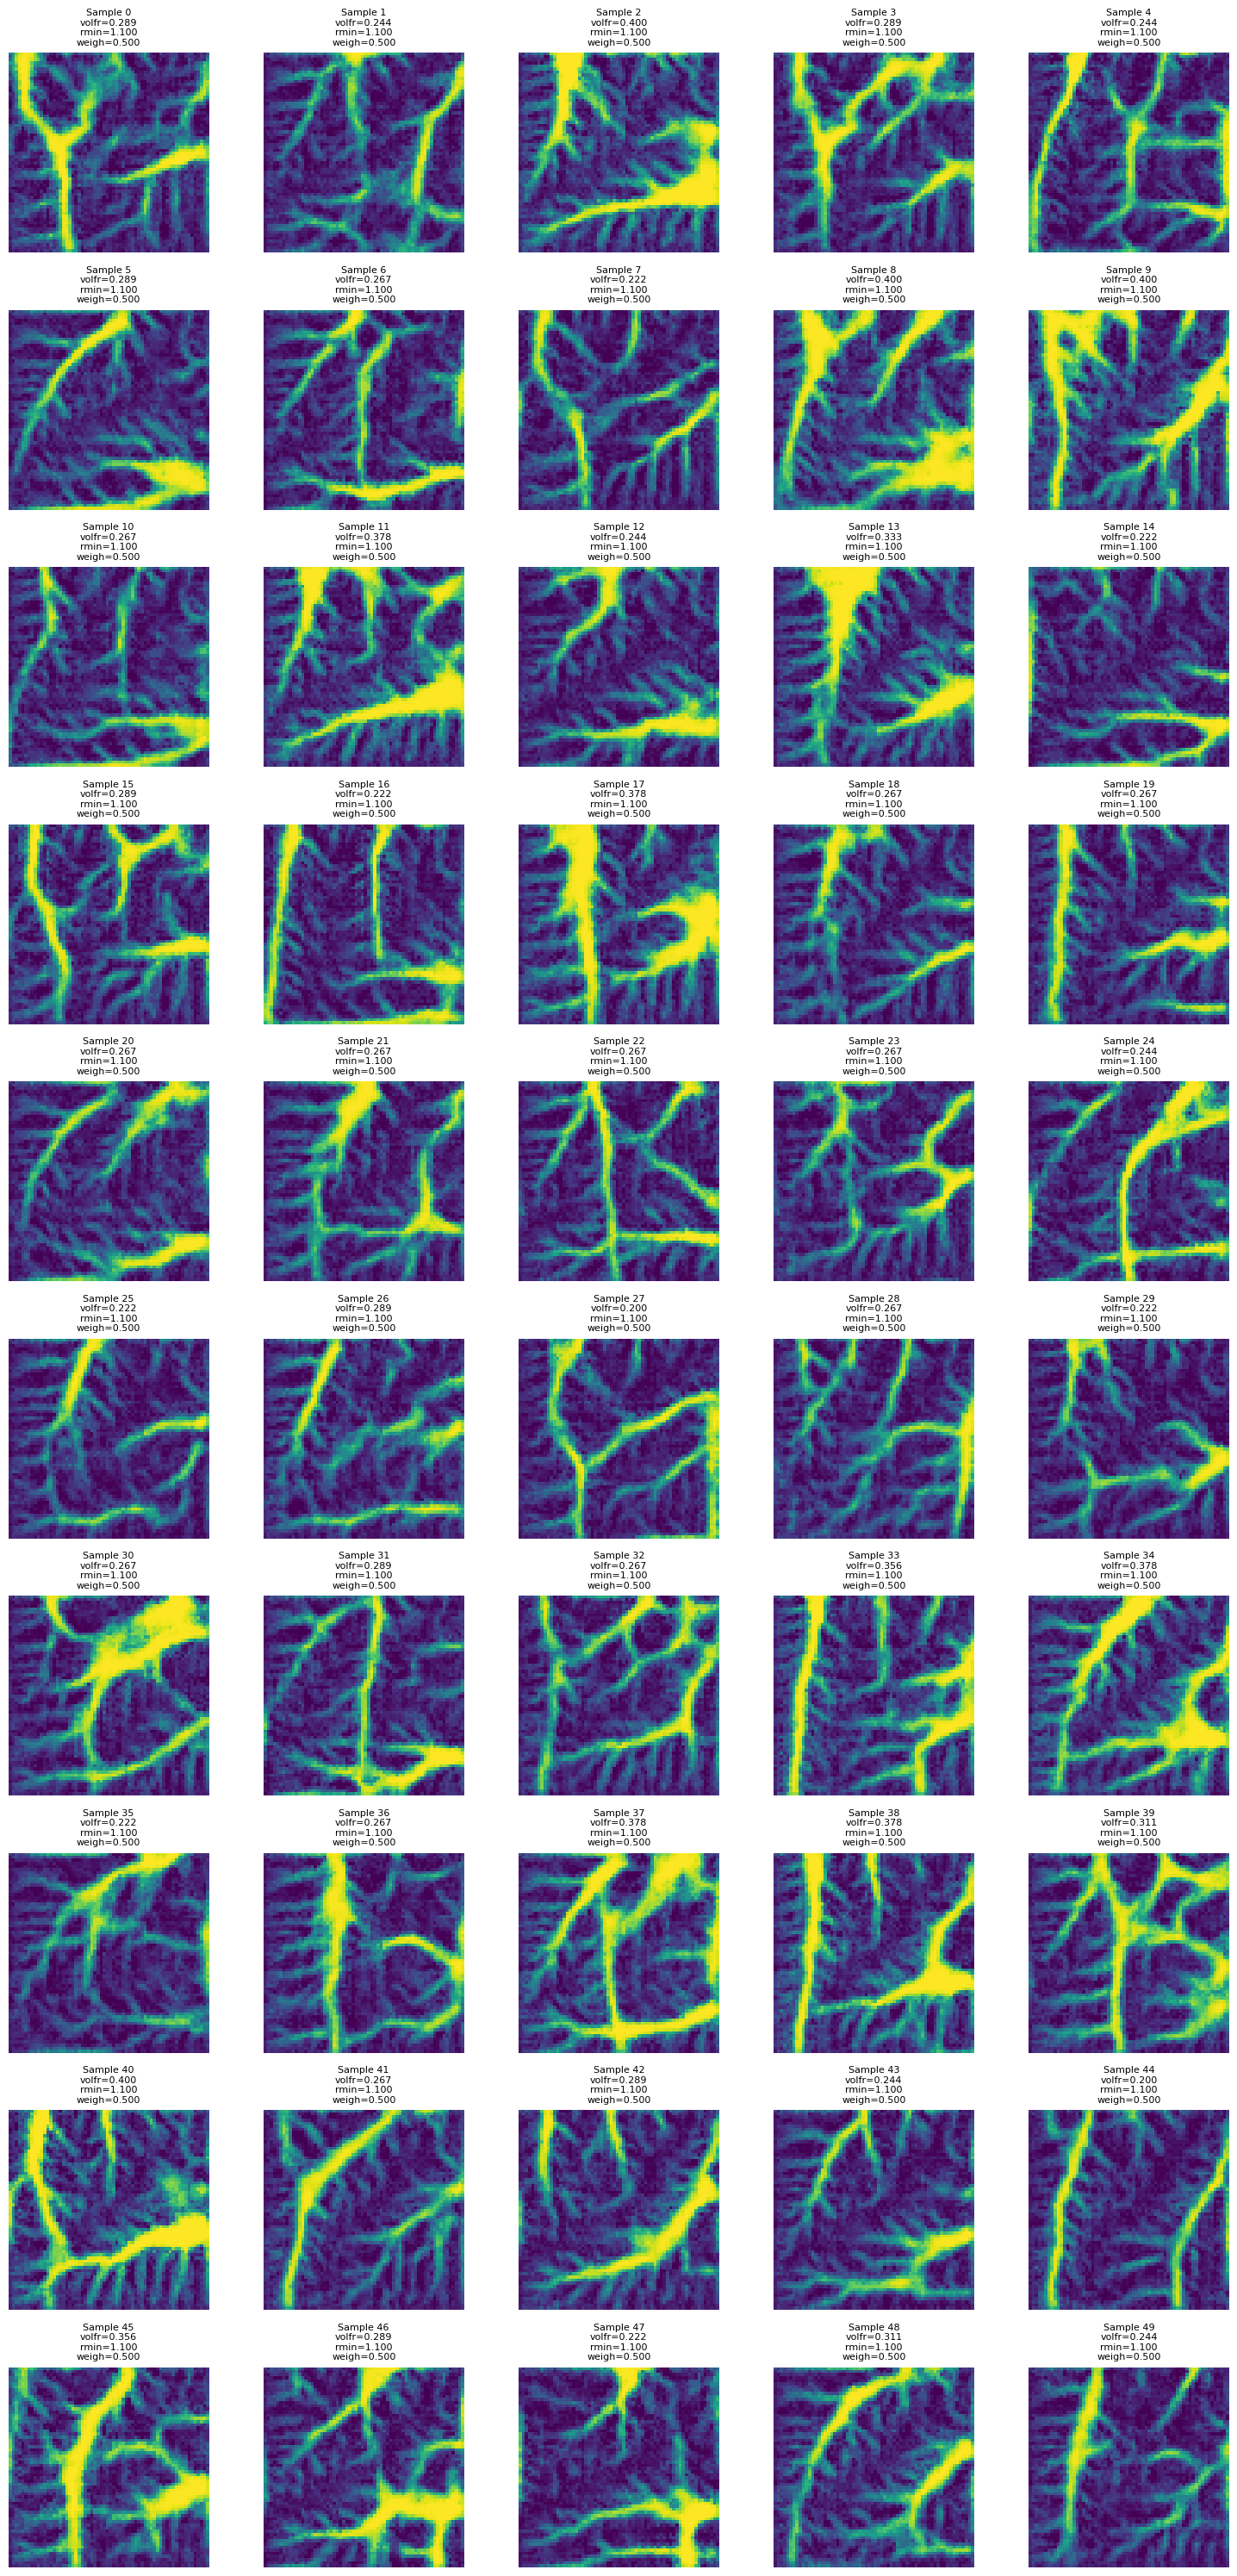


Showing 50 of 100 generated designs


In [41]:
# Plot generated designs
n_cols = min(5, N_SAMPLES)
n_rows = min(10, (N_SAMPLES + n_cols - 1) // n_cols)  # Limit to 10 rows for display
n_display = min(N_SAMPLES, n_rows * n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
if n_cols == 1:
    axes = axes.reshape(-1, 1)

for i in range(n_display):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    
    # Plot design
    im = ax.imshow(gen_designs_np[i], cmap='viridis', vmin=0, vmax=1)
    
    # Add title with conditions
    cond_str = "\n".join([f"{k[:5]}={conditions_np[j, i]:.3f}"
                          for j, k in enumerate(scalar_cond_keys)])
    ax.set_title(f"Sample {i}\n{cond_str}", fontsize=8)
    ax.axis('off')

# Hide extra subplots
for i in range(n_display, n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

if N_SAMPLES > n_display:
    print(f"\nShowing {n_display} of {N_SAMPLES} generated designs")

In [42]:
from ipywidgets import interact, FloatSlider, VBox, HBox, Output, Label
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# Sort conditions by each scalar condition key
sorted_indices = {}
sorted_conditions = {}

for j, key in enumerate(scalar_cond_keys):
    # Get condition values for this key
    cond_values = conditions_np[j, :]
    # Sort indices by increasing condition value
    sorted_idx = np.argsort(cond_values)
    sorted_indices[key] = sorted_idx
    sorted_conditions[key] = cond_values[sorted_idx]

print("Sorted conditions by each scalar key:")
for key in scalar_cond_keys:
    print(f"\n{key}:")
    print(f"  Min: {sorted_conditions[key].min():.4f}")
    print(f"  Max: {sorted_conditions[key].max():.4f}")
    print(f"  Range: {sorted_conditions[key]}")

# Create sliders for each scalar condition
sliders = {}
for j, key in enumerate(scalar_cond_keys):
    min_val = float(sorted_conditions[key].min())
    max_val = float(sorted_conditions[key].max())
    
    sliders[key] = FloatSlider(
        value=min_val,
        min=min_val,
        max=max_val,
        step=(max_val - min_val) / 100 if max_val > min_val else 0.01,
        description=f'{key}:',
        continuous_update=True,
        readout=True,
        readout_format='.4f',
    )

# Function to find the closest sample to slider values
def find_closest_sample(**slider_values):
    # Calculate distance to each sample
    problem.reset(seed=SEED)  # Reset problem for consistency
    distances = np.zeros(N_SAMPLES)
    
    for j, key in enumerate(scalar_cond_keys):
        target_value = slider_values[key]
        # Normalize by range to give equal weight to each condition
        cond_range = sorted_conditions[key].max() - sorted_conditions[key].min()
        if cond_range > 0:
            distances += ((conditions_np[j, :] - target_value) / cond_range) ** 2
        else:
            distances += (conditions_np[j, :] - target_value) ** 2
    
    # Find closest sample
    closest_idx = int(np.argmin(distances))
    
    # Clear and display
    clear_output(wait=True)
    
    # Create comparison plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    
    # Display generated design from original model
    axes[0].imshow(gen_designs_np[closest_idx], cmap='viridis', vmin=0, vmax=1)
    axes[0].set_title(f'{MODEL_TYPE}\n(Closest Match)', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    
    # Display dataset design
    axes[1].imshow(sampled_designs_np[closest_idx], cmap='viridis', vmin=0, vmax=1)
    axes[1].set_title('Dataset Design\n(Closest Match)', fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # # Optimize generated design
    # opt_config = _numpy_config(sampled_conditions[closest_idx])
    # opt_design, steps = problem.optimize(gen_designs_np[closest_idx], opt_config)
    # axes[2].imshow(opt_design, cmap='viridis', vmin=0, vmax=1)
    # axes[2].set_title('Optimized Generated Design\n(Closest Match)', fontsize=12, fontweight='bold')
    # axes[2].axis('off')

    # Add condition information as suptitle
    cond_info = []
    for j, key in enumerate(scalar_cond_keys):
        target = slider_values[key]
        actual = conditions_np[j, closest_idx]
        cond_info.append(f"{key}: target={target:.4e}, actual={actual:.4e}")
    
    fig.suptitle(f"Sample {closest_idx} | " + " | ".join(cond_info), 
                 fontsize=11, y=0.98)
    
    plt.tight_layout()
    plt.show()
    
    w = _sample_obj_weights(opt_config)
    print(f"\nClosest sample: {closest_idx}")
    print(f"Distance: {np.sqrt(distances[closest_idx]):.6e}")
    print(f"\nCondition comparison:")
    for j, key in enumerate(scalar_cond_keys):
        target = slider_values[key]
        actual = conditions_np[j, closest_idx]
        diff = actual - target
        objective = sampled_obj[closest_idx]
        print(f"  {key:15s}: target={target:8.4e}, actual={actual:8.4e}, diff={diff:+8.4e}")
        print(f"    Actual Objective: {objective:.4e}")
        print(f"    Gen-Optimized Objective: {_scalar_obj(steps[-1].obj_values, w):.4e}")

# Create interactive widget
interact(find_closest_sample, **sliders)

Sorted conditions by each scalar key:

volfrac:
  Min: 0.2000
  Max: 0.4000
  Range: [0.2        0.2        0.2        0.22222222 0.22222222 0.22222222
 0.22222222 0.22222222 0.22222222 0.22222222 0.22222222 0.22222222
 0.22222222 0.22222222 0.22222222 0.24444444 0.24444444 0.24444444
 0.24444444 0.24444444 0.24444444 0.24444444 0.24444444 0.24444444
 0.24444444 0.24444444 0.24444444 0.26666668 0.26666668 0.26666668
 0.26666668 0.26666668 0.26666668 0.26666668 0.26666668 0.26666668
 0.26666668 0.26666668 0.26666668 0.26666668 0.26666668 0.26666668
 0.26666668 0.2888889  0.2888889  0.2888889  0.2888889  0.2888889
 0.2888889  0.2888889  0.2888889  0.2888889  0.2888889  0.2888889
 0.2888889  0.2888889  0.2888889  0.2888889  0.2888889  0.2888889
 0.2888889  0.31111112 0.31111112 0.31111112 0.31111112 0.31111112
 0.31111112 0.31111112 0.31111112 0.31111112 0.31111112 0.33333334
 0.33333334 0.33333334 0.33333334 0.35555556 0.35555556 0.37777779
 0.37777779 0.37777779 0.37777779 0.37777779 0.

interactive(children=(FloatSlider(value=0.20000000298023224, description='volfrac:', max=0.4000000059604645, m…

<function __main__.find_closest_sample(**slider_values)>

In [43]:
idx = 3  # Index of the sample to optimize

# Ground truth objective stored in huggingface dataset (weighted-sum for multi-obj)
ground_truth_obj = sampled_obj[idx]

# Per-sample objective weights for multi-objective reduction
config = _numpy_config(sampled_conditions[idx])
obj_weights = _sample_obj_weights(config)

# Simulate reference design from dataset
problem.reset(seed=SEED)
ref_obj = problem.simulate(design=sampled_designs_np[idx], config=config)

# Simulate generated design before optimization
problem.reset(seed=SEED)
obj_gen = problem.simulate(design=gen_designs_np[idx], config=config)

# Optimize generated design  (float design, matching what the evaluation script does)
problem.reset(seed=SEED)
opt_gen_design, opt_history = problem.optimize(starting_point=gen_designs_np[idx], config=config)

# Re-optimize dataset design from the dataset design as starting point
problem.reset(seed=SEED)
opt_ref_design, opt_ref_history = problem.optimize(starting_point=sampled_designs_np[idx], config=config)

 It.:    1 Obj.:   835.9261 Vol.:  0.307 ch.:  0.009 || t_forward: 0.100 + t_sensitivity: 0.043 + t_sens_calc: 0.030 + t_mma:  0.040 =  0.214
 It.:    2 Obj.:   729.6455 Vol.:  0.302 ch.:  0.009 || t_forward: 0.101 + t_sensitivity: 0.044 + t_sens_calc: 0.028 + t_mma:  0.037 =  0.210
 It.:    3 Obj.:   654.5485 Vol.:  0.261 ch.:  0.179 || t_forward: 0.101 + t_sensitivity: 0.042 + t_sens_calc: 0.027 + t_mma:  0.014 =  0.184
 It.:    4 Obj.:   215.4778 Vol.:  0.271 ch.:  0.165 || t_forward: 0.107 + t_sensitivity: 0.044 + t_sens_calc: 0.027 + t_mma:  0.012 =  0.190
 It.:    5 Obj.:   114.5201 Vol.:  0.277 ch.:  0.158 || t_forward: 0.099 + t_sensitivity: 0.043 + t_sens_calc: 0.028 + t_mma:  0.015 =  0.185
 It.:    6 Obj.:    76.8031 Vol.:  0.281 ch.:  0.157 || t_forward: 0.105 + t_sensitivity: 0.044 + t_sens_calc: 0.027 + t_mma:  0.016 =  0.191
 It.:    7 Obj.:    57.9540 Vol.:  0.283 ch.:  0.153 || t_forward: 0.103 + t_sensitivity: 0.043 + t_sens_calc: 0.028 + t_mma:  0.015 =  0.189
 It.: 

In [44]:
print(problem.dataset["test"][int(selected_indices[idx])])
print(config)

ref_scalar = _scalar_obj(ref_obj, obj_weights)
gen_scalar = _scalar_obj(obj_gen, obj_weights)
opt_gen_scalar = _scalar_obj(opt_history[-1].obj_values, obj_weights)
opt_ref_scalar = _scalar_obj(opt_ref_history[-1].obj_values, obj_weights)

print("\nObjective comparison (scalar — weighted-sum for multi-objective):")
print(f"Ground truth objective from dataset: {ground_truth_obj:.4e}")
print(f"Re-simulated objective of dataset design: {ref_scalar:.4e}")
print(f"Simulated objective of generated design: {gen_scalar:.4e}")
print(f"Final objective of optimized generated design: {opt_gen_scalar:.4e}")
print(f"Final objective of re-optimized dataset design: {opt_ref_scalar:.4e}")
if n_objs > 1:
    print(f"\nRaw multi-objective values:")
    print(f"  ref_obj (dataset):    {ref_obj}")
    print(f"  obj_gen (generated):  {obj_gen}")
    print(f"  obj_weights:          {obj_weights}")

{'optimal_design': [[0.1400146484375, 0.204833984375, 0.2489013671875, 0.28125, 0.30419921875, 0.31103515625, 0.3349609375, 0.35888671875, 0.380126953125, 0.39013671875, 0.416748046875, 0.434326171875, 0.443603515625, 0.47900390625, 0.56005859375, 0.75439453125, 0.93603515625, 0.99609375, 1.0, 1.0, 1.0, 0.9765625, 0.66064453125, 0.1875, 0.07440185546875, 0.09002685546875, 0.09100341796875, 0.0831298828125, 0.1219482421875, 0.279296875, 0.296630859375, 0.2457275390625, 0.1492919921875, 0.09173583984375, 0.041412353515625, 0.1280517578125, 0.38818359375, 0.50537109375, 0.370361328125, 0.1451416015625, 0.03924560546875, 0.077880859375, 0.176513671875, 0.11749267578125, 0.011077880859375, 0.0460205078125, 0.33837890625, 0.67822265625, 0.79296875, 0.658203125, 0.564453125, 0.5244140625, 0.497802734375, 0.48779296875, 0.471435546875, 0.445556640625, 0.40625, 0.351318359375, 0.2978515625, 0.26123046875, 0.2244873046875, 0.1905517578125, 0.154296875, 0.1170654296875], [0.1409912109375, 0.12487

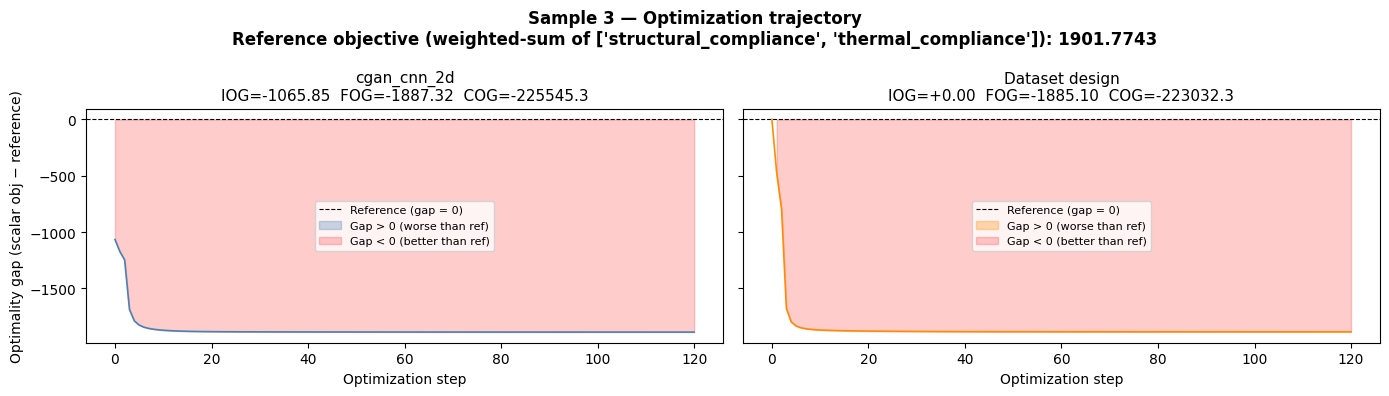

Generated  → IOG=-1065.8482  FOG=-1887.3165  COG=-225545.33
Dataset    → IOG=+0.0000  FOG=-1885.0969  COG=-223032.28

COG < 0 means the optimizer spent more steps BELOW the reference objective
than above it.  This can happen when the OC/SIMP steps are non-monotonic
(e.g. rapid binarisation of grey inputs overshoots the reference).


In [45]:
# Plot the full optimization trajectory to inspect COG behaviour.
# Each point is scalar_obj(opt.obj_values) - ref_scalar.  Negative = optimizer found
# better objective than the reference design at that step.
ref = ref_scalar

gen_gaps  = [_scalar_obj(s.obj_values, obj_weights) - ref for s in opt_history]
data_gaps = [_scalar_obj(s.obj_values, obj_weights) - ref for s in opt_ref_history]

cog_gen  = float(np.sum(gen_gaps))
cog_data = float(np.sum(data_gaps))
fog_gen  = gen_gaps[-1]
fog_data = data_gaps[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, gaps, label, cog, fog, color in [
    (axes[0], gen_gaps,  MODEL_TYPE,       cog_gen,  fog_gen,  'steelblue'),
    (axes[1], data_gaps, 'Dataset design',  cog_data, fog_data, 'darkorange'),
]:
    steps = range(len(gaps))
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', label='Reference (gap = 0)')
    ax.fill_between(steps, gaps, 0,
                    where=[g > 0 for g in gaps], color=color, alpha=0.3, label='Gap > 0 (worse than ref)')
    ax.fill_between(steps, gaps, 0,
                    where=[g < 0 for g in gaps], color='red', alpha=0.2, label='Gap < 0 (better than ref)')
    ax.plot(steps, gaps, color=color, linewidth=1.2)
    ax.set_title(f'{label}\nIOG={gaps[0]:+.2f}  FOG={fog:+.2f}  COG={cog:+.1f}', fontsize=11)
    ax.set_xlabel('Optimization step')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Optimality gap (scalar obj − reference)')
obj_label = f'weighted-sum of {problem.objectives_keys[:2]}' if n_objs > 1 else problem.objectives_keys[0]
fig.suptitle(
    f'Sample {idx} — Optimization trajectory\n'
    f'Reference objective ({obj_label}): {ref:.4f}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f'Generated  → IOG={gen_gaps[0]:+.4f}  FOG={fog_gen:+.4f}  COG={cog_gen:+.2f}')
print(f'Dataset    → IOG={data_gaps[0]:+.4f}  FOG={fog_data:+.4f}  COG={cog_data:+.2f}')
print()
print('COG < 0 means the optimizer spent more steps BELOW the reference objective')
print('than above it.  This can happen when the OC/SIMP steps are non-monotonic')
print('(e.g. rapid binarisation of grey inputs overshoots the reference).')

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

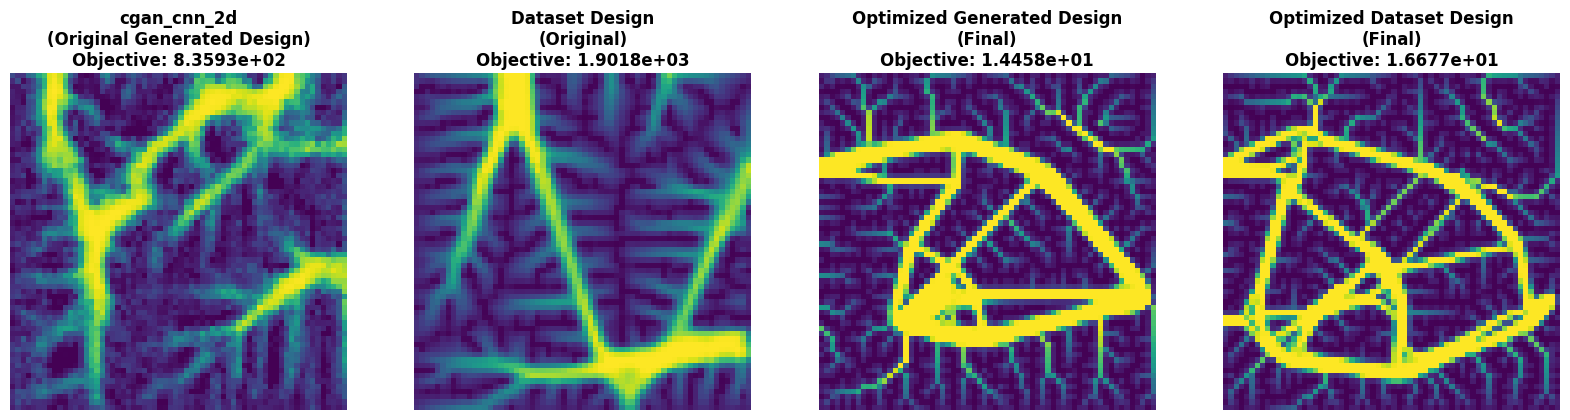

In [46]:
# Show images of generated design, dataset design, and optimized design
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Display generated design from original model
axes[0].imshow(gen_designs_np[idx], cmap='viridis', vmin=0, vmax=1)
axes[0].set_title(f'{MODEL_TYPE}\n(Original Generated Design)\nObjective: {gen_scalar:.4e}', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Display dataset design
axes[1].imshow(sampled_designs_np[idx], cmap='viridis', vmin=0, vmax=1)
axes[1].set_title(f'Dataset Design\n(Original)\nObjective: {ref_scalar:.4e}', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Display optimized generated design
axes[2].imshow(opt_gen_design, cmap='viridis', vmin=0, vmax=1)
axes[2].set_title(f'Optimized Generated Design\n(Final)\nObjective: {opt_gen_scalar:.4e}', fontsize=12, fontweight='bold')
axes[2].axis('off')

# Display reoptimized dataset design
axes[3].imshow(opt_ref_design, cmap='viridis', vmin=0)
axes[3].set_title(f'Optimized Dataset Design\n(Final)\nObjective: {opt_ref_scalar:.4e}', fontsize=12, fontweight='bold')
axes[3].axis('off')


 It.:    1 Obj.:    32.1173 Vol.:  0.288 ch.:  0.008 || t_forward: 0.114 + t_sensitivity: 0.038 + t_sens_calc: 0.027 + t_mma:  0.015 =  0.194
 It.:    2 Obj.:    31.5242 Vol.:  0.288 ch.:  0.008 || t_forward: 0.102 + t_sensitivity: 0.044 + t_sens_calc: 0.028 + t_mma:  0.014 =  0.188
 It.:    3 Obj.:    30.7763 Vol.:  0.274 ch.:  0.153 || t_forward: 0.112 + t_sensitivity: 0.045 + t_sens_calc: 0.029 + t_mma:  0.007 =  0.193
 It.:    4 Obj.:    23.4483 Vol.:  0.281 ch.:  0.137 || t_forward: 0.106 + t_sensitivity: 0.043 + t_sens_calc: 0.029 + t_mma:  0.009 =  0.187
 It.:    5 Obj.:    18.4109 Vol.:  0.285 ch.:  0.140 || t_forward: 0.113 + t_sensitivity: 0.043 + t_sens_calc: 0.028 + t_mma:  0.011 =  0.196
 It.:    6 Obj.:    16.0431 Vol.:  0.286 ch.:  0.127 || t_forward: 0.104 + t_sensitivity: 0.043 + t_sens_calc: 0.028 + t_mma:  0.011 =  0.186
 It.:    7 Obj.:    14.8222 Vol.:  0.287 ch.:  0.110 || t_forward: 0.109 + t_sensitivity: 0.044 + t_sens_calc: 0.029 + t_mma:  0.010 =  0.192
 It.: 

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

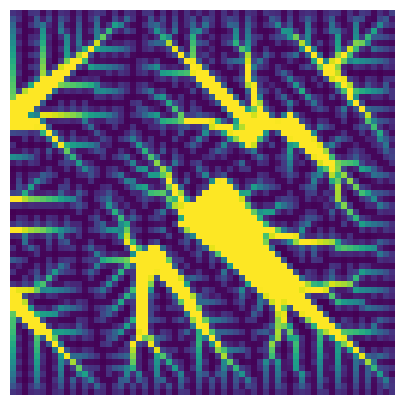

In [59]:
test_volfrac = np.ones_like(sampled_designs_np[idx])*0.2888888888888889
test_opt = problem.optimize(starting_point=test_volfrac, config=config)

# Display test optimized design
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(test_opt[0], cmap='viridis', vmin=0, vmax=1)
#ax.set_title(f'Test Optimized Design\n(Starting from uniform volfrac)\nObjective: {_scalar_obj(test_opt[1].obj_values, obj_weights):.4e}', fontsize=12, fontweight='bold')
ax.axis('off')

In [58]:
# Change the config weight to 1
config["weight"] = 0

## Part 2: LVAE Encode-Decode Analysis

This section loads a trained Least Volume Autoencoder (LVAE) and passes the generated/dataset designs through its encoder-decoder.
The goal is to see what information the LVAE smooths or loses relative to the original designs, and whether that affects optimization.

**Workflow:**
1. Configure and load a specific LVAE by its `nmse_threshold_rec` and `nmse_threshold_perf` values
2. Encode generated designs and dataset designs into LVAE latent space
3. Decode latent codes back to design space
4. Simulate and optimize decoded designs, comparing objectives to the originals

In [13]:
# ============ LVAE CONFIGURATION ============
LVAE_SEED = 1                    # LVAE training seed
REC_THRESHOLD = 0.001            # Reconstruction NMSE threshold
PERF_THRESHOLD = 1000.0           # Performance NMSE threshold (use 1000.0 for recon-only ablation)
LVAE_WANDB_PROJECT = "engiopt"
LVAE_WANDB_ENTITY = "engibench"  # Set to None to use default WandB entity


In [14]:
from engiopt.vanilla_lvae.utils import load_full_lvae, encode_designs

encoder, decoder, predictor, lvae_config = load_full_lvae(
    problem_id=PROBLEM_ID,
    seed=LVAE_SEED,
    rec_threshold=REC_THRESHOLD,
    perf_threshold=PERF_THRESHOLD,
    wandb_project=LVAE_WANDB_PROJECT,
    wandb_entity=LVAE_WANDB_ENTITY,
    device=DEVICE,
)
print(f'Loaded LVAE: latent_dim={lvae_config.latent_dim}, perf_dim={lvae_config.perf_dim}')
print(f'  nmse_threshold_rec:  {lvae_config.nmse_threshold_rec}')
print(f'  nmse_threshold_perf: {lvae_config.nmse_threshold_perf}')
print(f'  resize_dimensions:   {lvae_config.resize_dimensions}')


wandb: Downloading large artifact thermoelastic2d_constrained_vanilla_plvae_2d:seed_1_rec0.001_perf1000.0, 94.94MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.4


Loaded LVAE: latent_dim=100, perf_dim=100
  nmse_threshold_rec:  0.001
  nmse_threshold_perf: 1000
  resize_dimensions:   (100, 100)


### Encode and Decode

In [15]:
# Encode generated and dataset designs into LVAE latent space
z_gen = encode_designs(encoder, gen_designs_np, device=DEVICE)
z_data = encode_designs(encoder, sampled_designs_np, device=DEVICE)

# Count active (non-pruned) dimensions
active_dims_mask = np.var(z_data, axis=0) > 1e-8
n_active = int(active_dims_mask.sum())
print(f"Active latent dimensions: {n_active} / {lvae_config.latent_dim}")
print(f"z_gen shape:  {z_gen.shape}")
print(f"z_data shape: {z_data.shape}")


def decode_latents(decoder, z: np.ndarray, device: str, batch_size: int = 64) -> np.ndarray:
    """Decode latent codes to designs.

    Returns array of shape (N, H_decoder, W_decoder) — uses the decoder's
    internal design_shape (from lvae_config), which may differ from the
    problem's design_shape.  Caller is responsible for any further resize.
    """
    decoder.eval()
    z_t = th.from_numpy(z).float()
    decoded = []
    with th.no_grad():
        for i in range(0, len(z_t), batch_size):
            batch = z_t[i : i + batch_size].to(device)
            out = decoder(batch)          # (B, 1, H_decoder, W_decoder)
            decoded.append(out.squeeze(1).cpu().numpy())  # (B, H_decoder, W_decoder)
    return np.concatenate(decoded, axis=0)


decoded_gen_raw = decode_latents(decoder, z_gen, DEVICE)
decoded_data_raw = decode_latents(decoder, z_data, DEVICE)
print(f"\nDecoder output shape: {decoded_gen_raw.shape}  (lvae design_shape: {lvae_config.design_shape})")

# Resize to the problem's design_shape if the LVAE was trained on a different resolution
import torch.nn.functional as F

if tuple(decoded_gen_raw.shape[1:]) != tuple(design_shape):
    print(f"Resizing from {decoded_gen_raw.shape[1:]} to {design_shape}...")
    decoded_gen_t  = th.from_numpy(decoded_gen_raw ).unsqueeze(1)
    decoded_data_t = th.from_numpy(decoded_data_raw).unsqueeze(1)
    decoded_gen_np  = F.interpolate(decoded_gen_t,  size=design_shape, mode="bilinear", align_corners=False).squeeze(1).numpy()
    decoded_data_np = F.interpolate(decoded_data_t, size=design_shape, mode="bilinear", align_corners=False).squeeze(1).numpy()
else:
    decoded_gen_np  = decoded_gen_raw
    decoded_data_np = decoded_data_raw

decoded_gen_np  = np.clip(decoded_gen_np,  0.0, 1.0)
decoded_data_np = np.clip(decoded_data_np, 0.0, 1.0)

print(f"Final decoded shape: gen={decoded_gen_np.shape}, data={decoded_data_np.shape}")

# Pixel-level NMSE between original and decoded
nmse_gen  = np.mean((decoded_gen_np  - gen_designs_np    ) ** 2) / (np.var(gen_designs_np)     + 1e-8)
nmse_data = np.mean((decoded_data_np - sampled_designs_np) ** 2) / (np.var(sampled_designs_np) + 1e-8)
print(f"\nNMSE (gen encode-decode):  {nmse_gen:.6f}")
print(f"NMSE (data encode-decode): {nmse_data:.6f}")

Active latent dimensions: 100 / 100
z_gen shape:  (100, 100)
z_data shape: (100, 100)

Decoder output shape: (100, 64, 64)  (lvae design_shape: (64, 64))
Final decoded shape: gen=(100, 64, 64), data=(100, 64, 64)

NMSE (gen encode-decode):  0.411225
NMSE (data encode-decode): 0.317363


### Gallery: Original vs Decoded

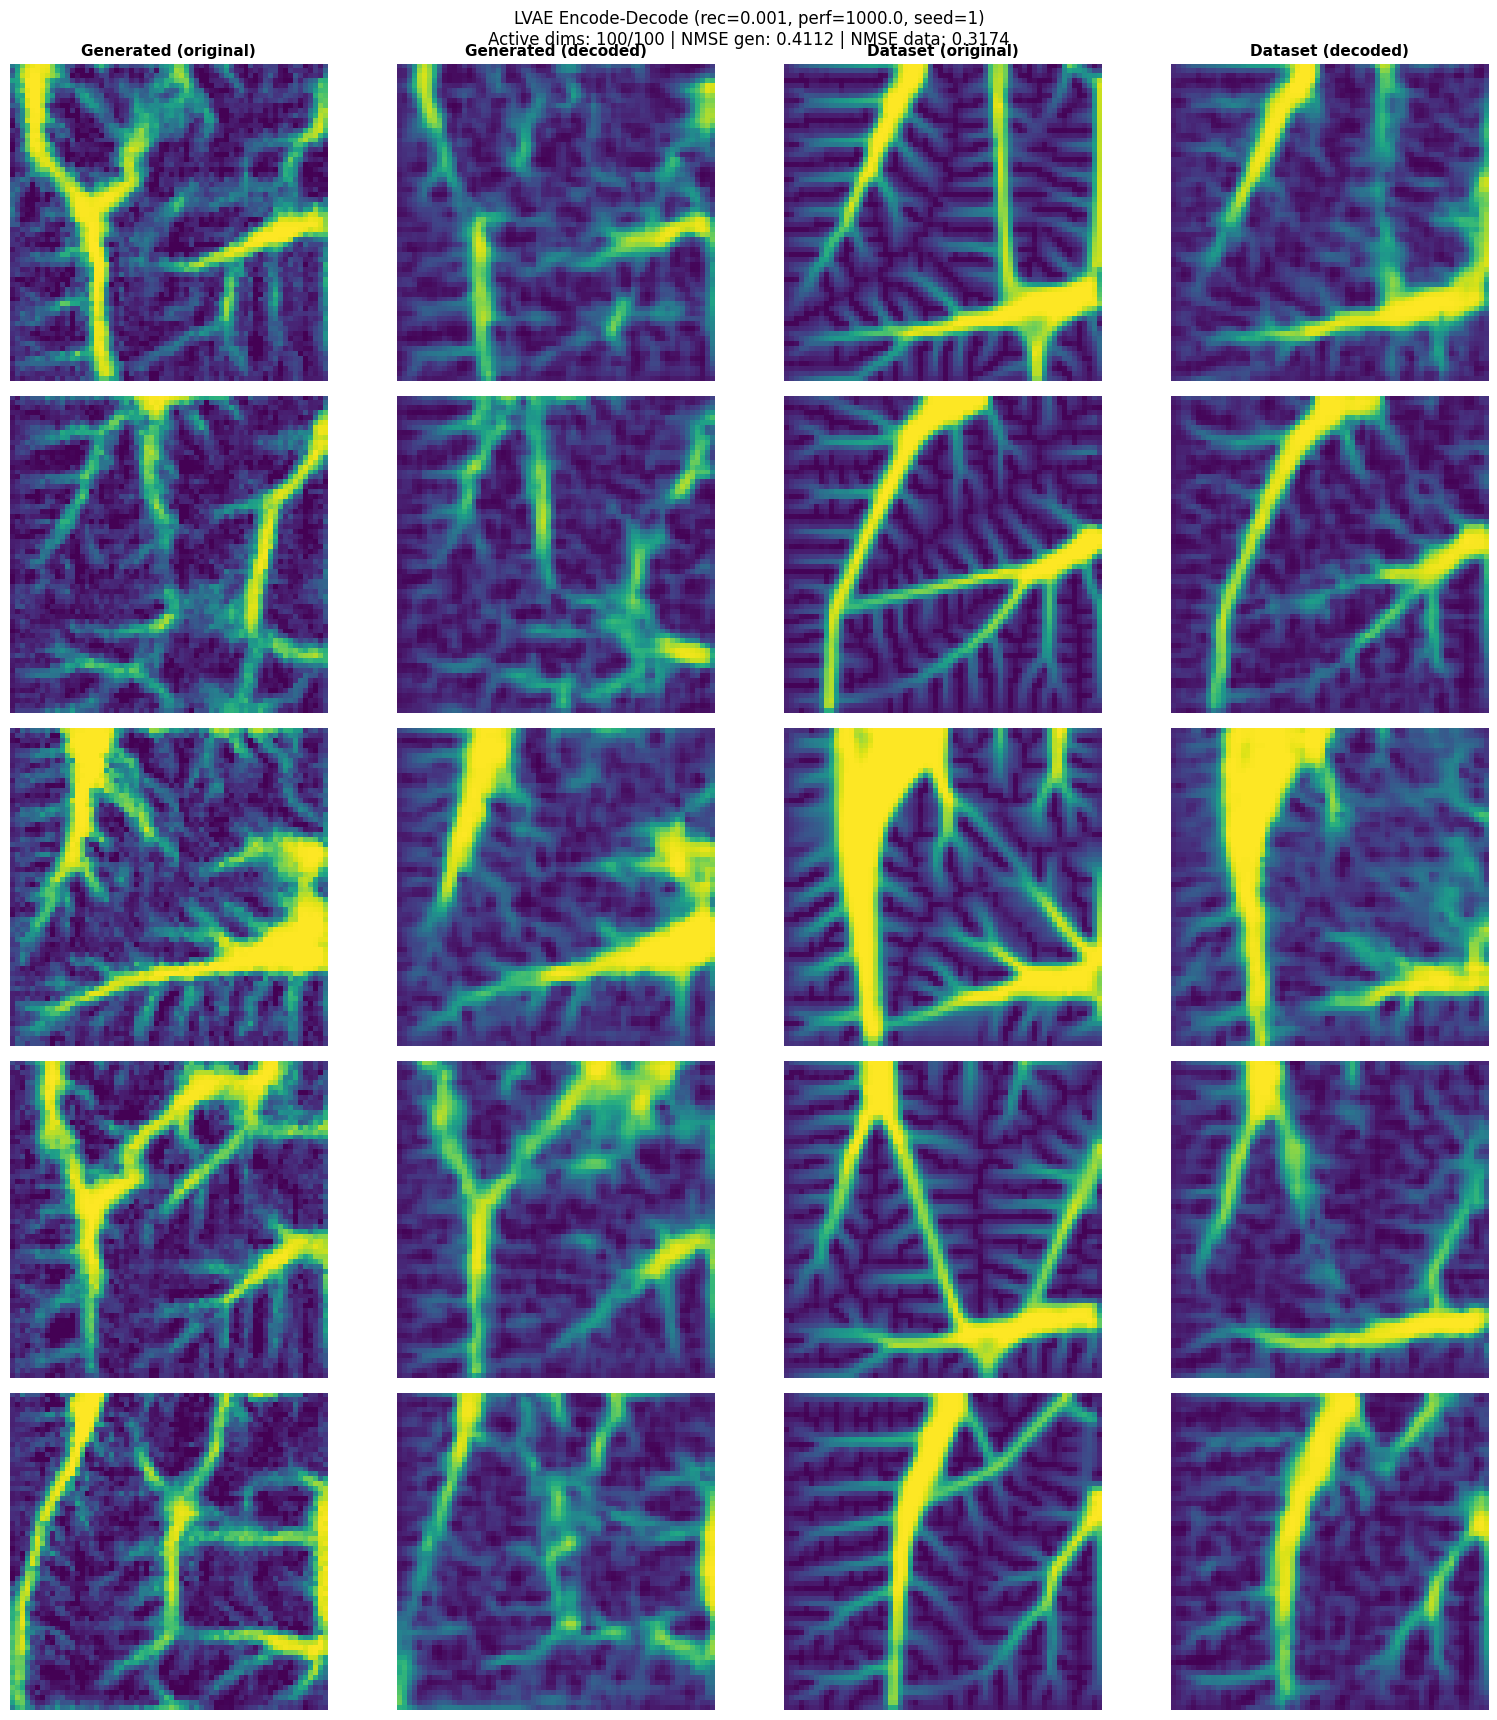

In [16]:
N_DISPLAY_LVAE = min(5, N_SAMPLES)

fig, axes = plt.subplots(N_DISPLAY_LVAE, 4, figsize=(16, 3.5 * N_DISPLAY_LVAE))
if N_DISPLAY_LVAE == 1:
    axes = axes.reshape(1, -1)

col_titles = ['Generated (original)', 'Generated (decoded)', 'Dataset (original)', 'Dataset (decoded)']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=11, fontweight='bold')

for i in range(N_DISPLAY_LVAE):
    axes[i, 0].imshow(gen_designs_np[i], cmap='viridis', vmin=0, vmax=1)
    axes[i, 0].axis('off')
    axes[i, 1].imshow(decoded_gen_np[i], cmap='viridis', vmin=0, vmax=1)
    axes[i, 1].axis('off')
    axes[i, 2].imshow(sampled_designs_np[i], cmap='viridis', vmin=0, vmax=1)
    axes[i, 2].axis('off')
    axes[i, 3].imshow(decoded_data_np[i], cmap='viridis', vmin=0, vmax=1)
    axes[i, 3].axis('off')

plt.suptitle(
    f'LVAE Encode-Decode (rec={REC_THRESHOLD}, perf={PERF_THRESHOLD}, seed={LVAE_SEED})\n'
    f'Active dims: {n_active}/{lvae_config.latent_dim} | '
    f'NMSE gen: {nmse_gen:.4f} | NMSE data: {nmse_data:.4f}',
    fontsize=12,
)
plt.tight_layout()
plt.show()


### Single-Sample: Simulate and Optimize Decoded Designs

In [17]:
lvae_idx = idx  # Change to inspect a different sample

lvae_config_cond = _numpy_config(sampled_conditions[lvae_idx])
lvae_obj_w = _sample_obj_weights(lvae_config_cond)

# Simulate decoded designs
problem.reset(seed=SEED)
obj_decoded_gen = problem.simulate(design=decoded_gen_np[lvae_idx], config=lvae_config_cond)


problem.reset(seed=SEED)
obj_decoded_data = problem.simulate(design=decoded_data_np[lvae_idx], config=lvae_config_cond)

# Optimize decoded generated design
problem.reset(seed=SEED)
opt_decoded_gen_design, opt_decoded_gen_history = problem.optimize(
    starting_point=decoded_gen_np[lvae_idx], config=lvae_config_cond
)

# Optimize decoded dataset design
problem.reset(seed=SEED)
opt_decoded_data_design, opt_decoded_data_history = problem.optimize(
    starting_point=decoded_data_np[lvae_idx], config=lvae_config_cond
)

print(f'Sample {lvae_idx} | LVAE: rec={REC_THRESHOLD}, perf={PERF_THRESHOLD}, seed={LVAE_SEED}')
print(f'Active dims: {n_active}/{lvae_config.latent_dim}')
print()
print('Generated design:')
print(f'  Original objective:            {_scalar_obj(obj_gen, lvae_obj_w):.4e}')
print(f'  After encode-decode:           {_scalar_obj(obj_decoded_gen, lvae_obj_w):.4e}')
print(f'  Optimized from original:       {_scalar_obj(opt_history[-1].obj_values, lvae_obj_w):.4e}')
print(f'  Optimized from decoded:        {_scalar_obj(opt_decoded_gen_history[-1].obj_values, lvae_obj_w):.4e}')
print()
print('Dataset design:')
print(f'  Original objective:            {_scalar_obj(ref_obj, lvae_obj_w):.4e}')
print(f'  After encode-decode:           {_scalar_obj(obj_decoded_data, lvae_obj_w):.4e}')
print(f'  Optimized from original:       {_scalar_obj(opt_ref_history[-1].obj_values, lvae_obj_w):.4e}')
print(f'  Optimized from decoded:        {_scalar_obj(opt_decoded_data_history[-1].obj_values, lvae_obj_w):.4e}')

 It.:    1 Obj.:  4778.2867 Vol.:  0.296 ch.:  0.009 || t_forward: 0.102 + t_sensitivity: 0.043 + t_sens_calc: 0.031 + t_mma:  0.032 =  0.207
 It.:    2 Obj.:  2817.6132 Vol.:  0.291 ch.:  0.009 || t_forward: 0.103 + t_sensitivity: 0.043 + t_sens_calc: 0.029 + t_mma:  0.033 =  0.207
 It.:    3 Obj.:  1865.1477 Vol.:  0.262 ch.:  0.180 || t_forward: 0.100 + t_sensitivity: 0.043 + t_sens_calc: 0.029 + t_mma:  0.012 =  0.184
 It.:    4 Obj.:   214.8539 Vol.:  0.273 ch.:  0.160 || t_forward: 0.108 + t_sensitivity: 0.043 + t_sens_calc: 0.029 + t_mma:  0.012 =  0.192
 It.:    5 Obj.:   111.9715 Vol.:  0.278 ch.:  0.164 || t_forward: 0.103 + t_sensitivity: 0.044 + t_sens_calc: 0.029 + t_mma:  0.012 =  0.188
 It.:    6 Obj.:    74.8956 Vol.:  0.281 ch.:  0.148 || t_forward: 0.109 + t_sensitivity: 0.042 + t_sens_calc: 0.028 + t_mma:  0.013 =  0.192
 It.:    7 Obj.:    57.0952 Vol.:  0.283 ch.:  0.144 || t_forward: 0.101 + t_sensitivity: 0.043 + t_sens_calc: 0.028 + t_mma:  0.012 =  0.184
 It.: 

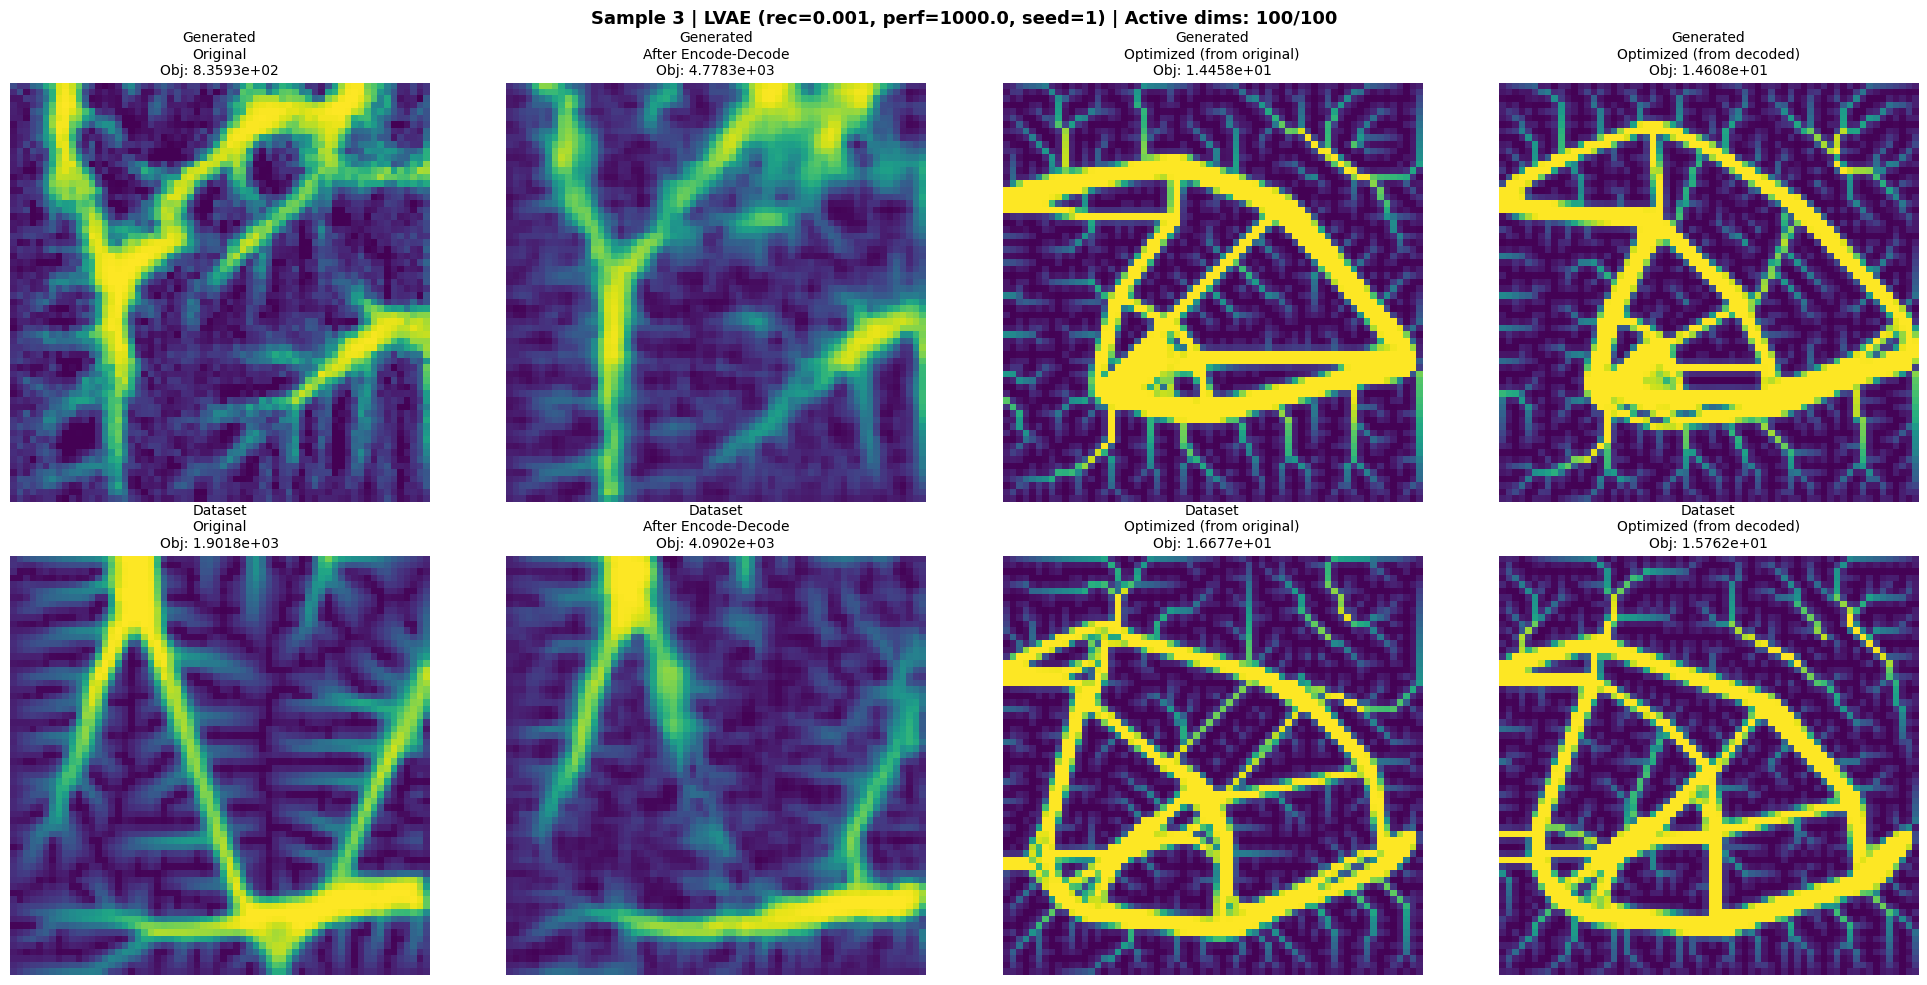

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

row_labels = ['Generated', 'Dataset']
col_labels = ['Original', 'After Encode-Decode', 'Optimized (from original)', 'Optimized (from decoded)']

rows_data = [
    (gen_designs_np[lvae_idx], decoded_gen_np[lvae_idx], opt_gen_design, opt_decoded_gen_design,
     _scalar_obj(obj_gen, lvae_obj_w), _scalar_obj(obj_decoded_gen, lvae_obj_w),
     _scalar_obj(opt_history[-1].obj_values, lvae_obj_w), _scalar_obj(opt_decoded_gen_history[-1].obj_values, lvae_obj_w)),
    (sampled_designs_np[lvae_idx], decoded_data_np[lvae_idx], opt_ref_design, opt_decoded_data_design,
     _scalar_obj(ref_obj, lvae_obj_w), _scalar_obj(obj_decoded_data, lvae_obj_w),
     _scalar_obj(opt_ref_history[-1].obj_values, lvae_obj_w), _scalar_obj(opt_decoded_data_history[-1].obj_values, lvae_obj_w)),
]

for row, (orig, dec, opt_o, opt_d, obj_o, obj_d, obj_oo, obj_od) in enumerate(rows_data):
    for col, (img, obj) in enumerate([
        (orig, obj_o), (dec, obj_d), (opt_o, obj_oo), (opt_d, obj_od)
    ]):
        axes[row, col].imshow(img, cmap='viridis', vmin=0, vmax=1)
        axes[row, col].set_title(
            f'{row_labels[row]}\n{col_labels[col]}\nObj: {obj:.4e}', fontsize=10
        )
        axes[row, col].axis('off')

plt.suptitle(
    f'Sample {lvae_idx} | LVAE (rec={REC_THRESHOLD}, perf={PERF_THRESHOLD}, seed={LVAE_SEED}) | '
    f'Active dims: {n_active}/{lvae_config.latent_dim}',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

# Part 3: Pre-Run Investigations — Benchmarking Pitfalls

These experiments identify pitfalls in evaluating generative models for engineering design,
before committing to the full 120-job SLURM evaluation run.

**Key questions:**
1. How much do generators produce out-of-bounds values? (Is clipping even doing anything?)
2. Do simulators crash on negative/zero designs?
3. Does clipping strategy change simulation objectives and optimization warmstart quality?
4. Does clipping systematically violate volume fraction constraints?
5. Do per-sample IOG/COG distributions reveal hidden failure modes?

**Background — simulator robustness:**
| Problem | Formula | Negative values | Zero | >1 |
|---|---|---|---|---|
| Beams2D | `Emin + x³(Emax-Emin)` | Crashes (negative stiffness) | Safe | Wrong but computes |
| HeatConduction2D | `ε + (1-ε)x⁵` | Crashes (negative conductivity) | Safe | Wrong but computes |
| Photonics2D | `tanh` projection → permittivity | Safe (tanh maps to [0,1]) | Safe | Safe |

## Experiment 1: Raw Generator Output Distribution

How much do generated designs go out of bounds? If generators already output [0,1], clipping is a no-op.
Run this cell after generating designs (cell above stores `gen_designs_raw`).

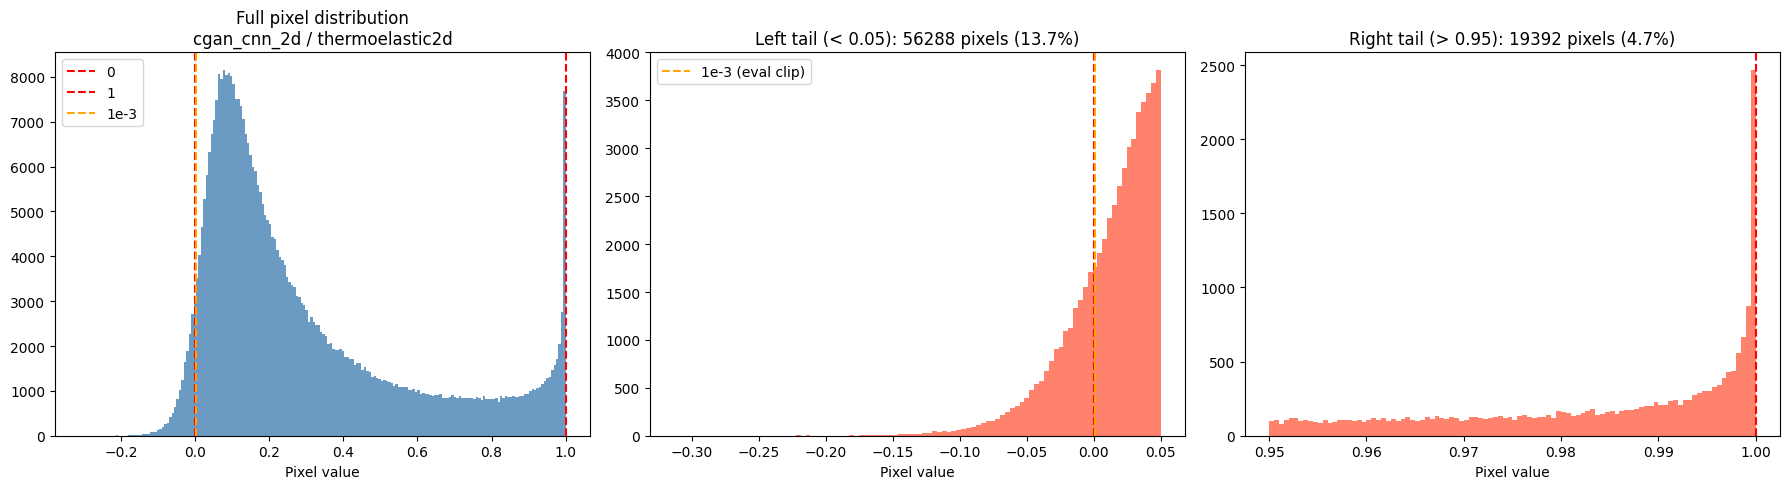


Model: cgan_cnn_2d | Problem: thermoelastic2d | N=100
Range: [-0.313269, 1.000000]
Pixels < 0:         16849 / 409600 (4.114%)
Pixels in [0, 1e-3):   439 / 409600 (0.107%)
Pixels > 1:             0 / 409600 (0.000%)
Pixels in [0, 1]:  392751 / 409600 (95.886%)

Worst sample (idx=57): 291 out-of-bounds pixels
  Range: [-0.153902, 0.997098]


In [19]:
# Experiment 1: Pixel value distribution of raw (unclipped) generated designs
# Requires: gen_designs_raw from the generation cell

raw = gen_designs_raw.flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full histogram
axes[0].hist(raw, bins=200, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].axvline(0, color="red", ls="--", label="0")
axes[0].axvline(1, color="red", ls="--", label="1")
axes[0].axvline(1e-3, color="orange", ls="--", label="1e-3")
axes[0].set_title(f"Full pixel distribution\n{MODEL_TYPE} / {PROBLEM_ID}")
axes[0].set_xlabel("Pixel value")
axes[0].legend()

# Zoom: left tail (values < 0.05)
left_tail = raw[raw < 0.05]
axes[1].hist(left_tail, bins=100, color="tomato", edgecolor="none", alpha=0.8)
axes[1].axvline(0, color="red", ls="--")
axes[1].axvline(1e-3, color="orange", ls="--", label="1e-3 (eval clip)")
axes[1].set_title(f"Left tail (< 0.05): {len(left_tail)} pixels ({100*len(left_tail)/len(raw):.1f}%)")
axes[1].set_xlabel("Pixel value")
axes[1].legend()

# Zoom: right tail (values > 0.95)
right_tail = raw[raw > 0.95]
axes[2].hist(right_tail, bins=100, color="tomato", edgecolor="none", alpha=0.8)
axes[2].axvline(1, color="red", ls="--")
axes[2].set_title(f"Right tail (> 0.95): {len(right_tail)} pixels ({100*len(right_tail)/len(raw):.1f}%)")
axes[2].set_xlabel("Pixel value")

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n{'='*60}")
print(f"Model: {MODEL_TYPE} | Problem: {PROBLEM_ID} | N={N_SAMPLES}")
print(f"{'='*60}")
print(f"Range: [{raw.min():.6f}, {raw.max():.6f}]")
print(f"Pixels < 0:      {(raw < 0).sum():>8d} / {len(raw)} ({100*(raw < 0).mean():.3f}%)")
print(f"Pixels in [0, 1e-3): {((raw >= 0) & (raw < 1e-3)).sum():>5d} / {len(raw)} ({100*((raw >= 0) & (raw < 1e-3)).mean():.3f}%)")
print(f"Pixels > 1:      {(raw > 1).sum():>8d} / {len(raw)} ({100*(raw > 1).mean():.3f}%)")
print(f"Pixels in [0, 1]: {((raw >= 0) & (raw <= 1)).sum():>7d} / {len(raw)} ({100*((raw >= 0) & (raw <= 1)).mean():.3f}%)")

# Per-sample: which samples have the most out-of-bounds pixels?
oob_per_sample = np.array([(d < 0).sum() + (d > 1).sum() for d in gen_designs_raw])
if oob_per_sample.max() > 0:
    worst_idx = np.argmax(oob_per_sample)
    print(f"\nWorst sample (idx={worst_idx}): {oob_per_sample[worst_idx]} out-of-bounds pixels")
    print(f"  Range: [{gen_designs_raw[worst_idx].min():.6f}, {gen_designs_raw[worst_idx].max():.6f}]")
else:
    print("\nAll samples are within [0, 1] — clipping is a no-op for this model/problem.")

## Experiment 4: What Happens with Negative/Zero Designs?

Do beams2d and heatconduction2d actually crash on negative values, or silently produce bad results?
Photonics2d has a tanh projection that should absorb out-of-bounds values.

In [20]:
# Experiment 4: Test simulator behavior with synthetic bad designs
# Tests: all-zeros, slightly negative, mixed negative, and binarized

# Use a real condition from the sampled set
test_config = _numpy_config(sampled_conditions[0])
test_obj_w = _sample_obj_weights(test_config)
print(f"Problem: {PROBLEM_ID}")
print(f"Test condition (scalar keys): { {k: test_config[k] for k in scalar_cond_keys if k in test_config} }")
print(f"Design shape: {design_shape}")
print()

# Create synthetic test designs
test_designs = {
    "all_zeros": np.zeros(design_shape),
    "all_1e-3": np.full(design_shape, 1e-3),
    "all_0.5": np.full(design_shape, 0.5),
    "slight_negative_(-0.01)": np.full(design_shape, -0.01),
    "negative_(-0.1)": np.full(design_shape, -0.1),
    "mixed_neg_pos": np.where(np.random.default_rng(42).random(design_shape) > 0.5, 0.8, -0.05),
    "real_sample_raw": gen_designs_raw[0].copy(),
    "real_sample_clip01": np.clip(gen_designs_raw[0], 0.0, 1.0),
    "real_sample_clip1e3": np.clip(gen_designs_raw[0], 1e-3, 1.0),
    "real_sample_binarize": (gen_designs_raw[0] > 0.5).astype(float),
}

results = {}
for name, design in test_designs.items():
    try:
        problem.reset(seed=42)
        obj = problem.simulate(design=design, config=test_config)
        obj_val = _scalar_obj(obj, test_obj_w)
        status = "OK"
        if np.isnan(obj_val) or np.isinf(obj_val):
            status = "NaN/Inf"
        results[name] = (status, obj_val)
        print(f"  {name:30s} -> {status:8s} obj={obj_val:.6e}")
    except Exception as e:
        results[name] = ('CRASH', str(e)[:80])
        print(f"  {name:30s} -> CRASH:   {str(e)[:80]}")

print(f"\n--- Summary ---")
for name, (status, val) in results.items():
    emoji = {"OK": "OK", "NaN/Inf": "!!", "CRASH": "XX"}[status]
    print(f"  [{emoji}] {name}")

Problem: thermoelastic2d
Test condition (scalar keys): {'volfrac': 0.2888888888888889, 'rmin': 1.1, 'weight': 0.5}
Design shape: (64, 64)

  all_zeros                      -> NaN/Inf  obj=nan


/Users/mkeeler/Desktop/Work/ETHZ/Research/EngiLearn/EngiBench/engibench/problems/thermoelastic2d/model/fem_setup.py:225: MatrixRankWarning: Matrix is exactly singular
  um[freedofsm] = spsolve(km[np.ix_(freedofsm, freedofsm)], fm[freedofsm])
/Users/mkeeler/Desktop/Work/ETHZ/Research/EngiLearn/EngiBench/engibench/problems/thermoelastic2d/model/fea_model.py:227: MatrixRankWarning: Matrix is exactly singular
  lamm_freedofs = -spsolve(km_ff, flam_freedofs)


  all_1e-3                       -> OK       obj=9.669815e+09
  all_0.5                        -> OK       obj=8.510159e+01
  slight_negative_(-0.01)        -> OK       obj=-1.082887e+07
  negative_(-0.1)                -> OK       obj=-1.426943e+04
  mixed_neg_pos                  -> OK       obj=-1.208017e+02
  real_sample_raw                -> OK       obj=2.639266e+03
  real_sample_clip01             -> NaN/Inf  obj=nan
  real_sample_clip1e3            -> OK       obj=2.803222e+03
  real_sample_binarize           -> NaN/Inf  obj=nan

--- Summary ---
  [!!] all_zeros
  [OK] all_1e-3
  [OK] all_0.5
  [OK] slight_negative_(-0.01)
  [OK] negative_(-0.1)
  [OK] mixed_neg_pos
  [OK] real_sample_raw
  [!!] real_sample_clip01
  [OK] real_sample_clip1e3
  [!!] real_sample_binarize


## Experiment 2: Clipping vs No-Clip vs Binarize → Simulate

How does post-processing change the objective value from `problem.simulate()`?
For beams2d, the SIMP formula `x³` amplifies small density differences.
For photonics2d, the tanh projection may absorb the difference entirely.

In [21]:
# Experiment 2: Simulate under different clipping strategies
N_TEST = 3  # Number of samples to test (keep small — each simulate() takes time)

clip_strategies = {
    "raw (no clip)": lambda x: x,
    "clip [0, 1]": lambda x: np.clip(x, 0.0, 1.0),
    "clip [1e-3, 1]": lambda x: np.clip(x, 1e-3, 1.0),
    "binarize (>0.5)": lambda x: (x > 0.5).astype(float),
}

print(f"Problem: {PROBLEM_ID} | Model: {MODEL_TYPE} | Testing {N_TEST} samples")
print(f"{'Sample':>6} | {'Strategy':>20} | {'Objective':>14} | {'Delta from ref':>14} | Status")
print('-' * 80)

sim_results = []
for i in range(N_TEST):
    config_i = _numpy_config(sampled_conditions[i])
    w_i = _sample_obj_weights(config_i)

    # Reference: simulate the dataset design
    problem.reset(seed=42)
    ref_obj_raw = problem.simulate(design=sampled_designs_np[i], config=config_i)
    ref_val = _scalar_obj(ref_obj_raw, w_i)
    print(f"{i:>6} | {'REFERENCE (dataset)':>20} | {ref_val:>14.4e} | {'---':>14} |")

    for strat_name, clip_fn in clip_strategies.items():
        design = clip_fn(gen_designs_raw[i])
        try:
            problem.reset(seed=42)
            obj = problem.simulate(design=design, config=config_i)
            obj_val = _scalar_obj(obj, w_i)
            delta = obj_val - ref_val
            status = "OK" if np.isfinite(obj_val) else "NaN/Inf"
            sim_results.append({'sample': i, 'strategy': strat_name, 'obj': obj_val, 'ref': ref_val, 'delta': delta})
            print(f"{i:>6} | {strat_name:>20} | {obj_val:>14.4e} | {delta:>+14.4e} | {status}")
        except Exception as e:
            sim_results.append({'sample': i, 'strategy': strat_name, 'obj': None, 'ref': ref_val, 'delta': None})
            print(f"{i:>6} | {strat_name:>20} | {'CRASH':>14} | {'---':>14} | {str(e)[:40]}")
    print()

Problem: thermoelastic2d | Model: cgan_cnn_2d | Testing 3 samples
Sample |             Strategy |      Objective | Delta from ref | Status
--------------------------------------------------------------------------------
     0 |  REFERENCE (dataset) |     1.2886e+04 |            --- |
     0 |        raw (no clip) |     2.6393e+03 |    -1.0247e+04 | OK
     0 |          clip [0, 1] |            nan |           +nan | NaN/Inf
     0 |       clip [1e-3, 1] |     2.8032e+03 |    -1.0083e+04 | OK
     0 |      binarize (>0.5) |            nan |           +nan | NaN/Inf

     1 |  REFERENCE (dataset) |     3.1139e+03 |            --- |
     1 |        raw (no clip) |     3.7130e+02 |    -2.7426e+03 | OK
     1 |          clip [0, 1] |            nan |           +nan | NaN/Inf
     1 |       clip [1e-3, 1] |     3.7660e+02 |    -2.7373e+03 | OK
     1 |      binarize (>0.5) |            nan |           +nan | NaN/Inf

     2 |  REFERENCE (dataset) |     6.0571e+02 |            --- |
     2 |

## Experiment 5: Volume Fraction Constraint Violations Under Different Clips

Does clipping change whether designs satisfy the volume fraction constraint?
`clip[1e-3, 1]` shifts mean density upward (no zeros), which may systematically violate volfrac.

Problem: thermoelastic2d | Model: cgan_cnn_2d | Volfrac key: volfrac
Testing 50 samples, tolerance = 0.01



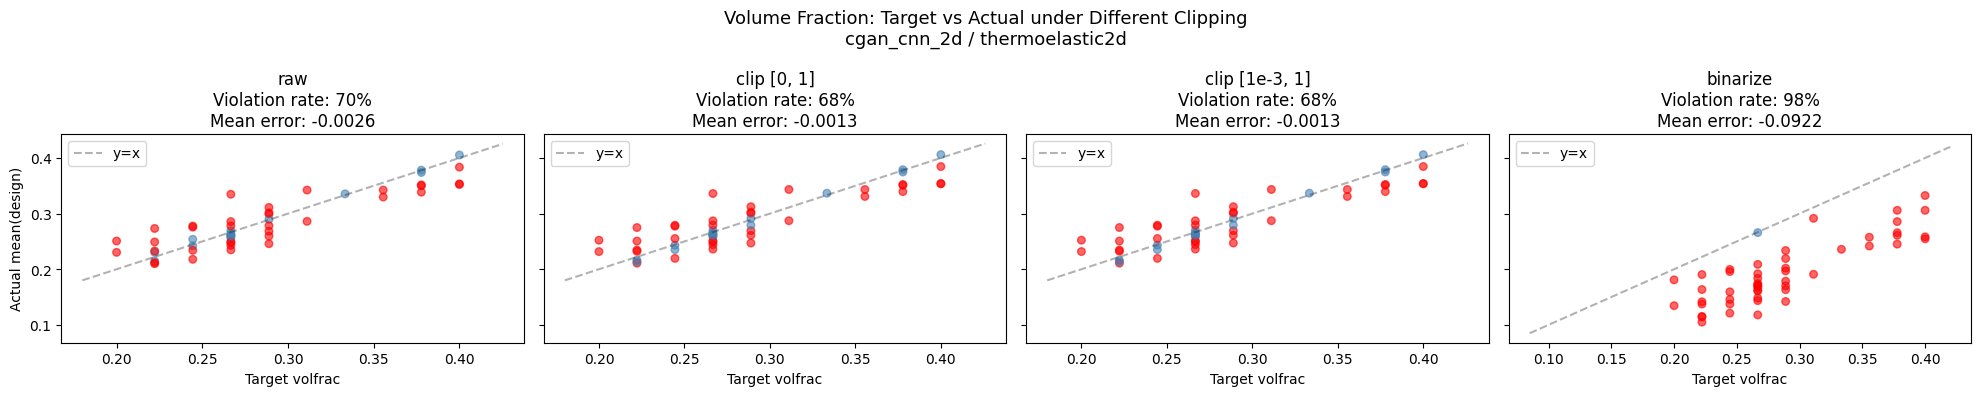

In [22]:
# Experiment 5: Volume fraction violations under different clipping
# Only meaningful for problems with a 'volfrac' or 'volume' condition

volfrac_key = None
for key in ['volfrac', 'volume']:
    if key in problem.conditions_keys:
        volfrac_key = key
        break

if volfrac_key is None:
    print(f"Problem {PROBLEM_ID} has no volfrac/volume condition — skipping.")
else:
    N_VOL_TEST = min(50, N_SAMPLES)
    target_volfracs = np.array([sampled_conditions[i][volfrac_key] for i in range(N_VOL_TEST)])

    clip_fns = {
        "raw": lambda x: x,
        "clip [0, 1]": lambda x: np.clip(x, 0.0, 1.0),
        "clip [1e-3, 1]": lambda x: np.clip(x, 1e-3, 1.0),
        "binarize": lambda x: (x > 0.5).astype(float),
    }

    print(f"Problem: {PROBLEM_ID} | Model: {MODEL_TYPE} | Volfrac key: {volfrac_key}")
    print(f"Testing {N_VOL_TEST} samples, tolerance = 0.01\n")

    fig, axes = plt.subplots(1, len(clip_fns), figsize=(5 * len(clip_fns), 4), sharey=True)

    for ax_idx, (strat_name, clip_fn) in enumerate(clip_fns.items()):
        actual_vfs = np.array([clip_fn(gen_designs_raw[i]).mean() for i in range(N_VOL_TEST)])
        errors = actual_vfs - target_volfracs
        violations = np.abs(errors) >= 0.01
        viol_rate = violations.mean()

        ax = axes[ax_idx]
        colors = ['red' if v else 'steelblue' for v in violations]
        ax.scatter(target_volfracs, actual_vfs, c=colors, alpha=0.6, s=30)
        lims = [min(target_volfracs.min(), actual_vfs.min()) - 0.02,
                max(target_volfracs.max(), actual_vfs.max()) + 0.02]
        ax.plot(lims, lims, 'k--', alpha=0.3, label='y=x')
        ax.set_xlabel('Target volfrac')
        if ax_idx == 0:
            ax.set_ylabel('Actual mean(design)')
        ax.set_title(f'{strat_name}\nViolation rate: {100*viol_rate:.0f}%\nMean error: {errors.mean():+.4f}')
        ax.legend()

    plt.suptitle(f'Volume Fraction: Target vs Actual under Different Clipping\n{MODEL_TYPE} / {PROBLEM_ID}', fontsize=13)
    plt.tight_layout()
    plt.show()


## Experiment 3: Clipping → Optimize (IOG/COG)

The core test: does post-processing change the optimization warmstart quality?
If yes, model rankings depend on an arbitrary post-processing choice.

**Warning**: This runs `problem.optimize()` for each strategy × sample (~2-5 min each).
With 3 samples × 4 strategies = 12 calls, expect ~30-60 minutes.

In [23]:
# Experiment 3: Optimize under different clipping strategies
N_OPT_TEST = 3  # Keep small! Each optimize() takes 2-5 minutes

opt_strategies = {
    "clip [0, 1]": lambda x: np.clip(x, 0.0, 1.0),
    "clip [1e-3, 1]": lambda x: np.clip(x, 1e-3, 1.0),
    "binarize (>0.5)": lambda x: (x > 0.5).astype(float),
}

print(f"Problem: {PROBLEM_ID} | Model: {MODEL_TYPE} | Testing {N_OPT_TEST} samples")
print(f"Strategies: {list(opt_strategies.keys())}")
print(f"Expected time: ~{N_OPT_TEST * len(opt_strategies) * 3} minutes\n")

opt_results = {}  # {sample_idx: {strategy: {iog, cog, fog, history}}}

for i in range(N_OPT_TEST):
    opt_results[i] = {}
    config_i = _numpy_config(sampled_conditions[i])
    w_i = _sample_obj_weights(config_i)

    # Reference: simulate dataset design
    problem.reset(seed=42)
    ref_obj_raw = problem.simulate(design=sampled_designs_np[i], config=config_i)
    ref_obj_val = _scalar_obj(ref_obj_raw, w_i)

    for strat_name, clip_fn in opt_strategies.items():
        design = clip_fn(gen_designs_raw[i])
        print(f"  Sample {i} | {strat_name} | design range [{design.min():.4f}, {design.max():.4f}]", end="")

        try:
            # Simulate initial design (IOG)
            problem.reset(seed=42)
            init_obj = problem.simulate(design=design, config=config_i)
            init_val = _scalar_obj(init_obj, w_i)
            iog = init_val - ref_obj_val

            # Optimize
            problem.reset(seed=42)
            _, history = problem.optimize(starting_point=design, config=config_i)
            obj_history = [_scalar_obj(h.obj_values, w_i) for h in history]
            gaps = [v - ref_obj_val for v in obj_history]
            cog = sum(gaps)
            fog = gaps[-1]

            opt_results[i][strat_name] = {
                'iog': iog, 'cog': cog, 'fog': fog,
                'obj_history': obj_history, 'gaps': gaps,
                'ref_obj': ref_obj_val,
            }
            print(f" -> IOG={iog:.4e}, COG={cog:.4e}, FOG={fog:.4e}")
        except Exception as e:
            opt_results[i][strat_name] = {'error': str(e)[:80]}
            print(f" -> CRASH: {str(e)[:60]}")

    print()

Problem: thermoelastic2d | Model: cgan_cnn_2d | Testing 3 samples
Strategies: ['clip [0, 1]', 'clip [1e-3, 1]', 'binarize (>0.5)']
Expected time: ~27 minutes

  Sample 0 | clip [0, 1] | design range [0.0000, 0.9999] It.:    1 Obj.:        nan Vol.:  0.301 ch.:  0.005 || t_forward: 0.101 + t_sensitivity: 0.037 + t_sens_calc: 0.031 + t_mma:  0.001 =  0.170
 It.:    2 Obj.:  2802.7686 Vol.:  0.297 ch.:  0.009 || t_forward: 0.101 + t_sensitivity: 0.043 + t_sens_calc: 0.029 + t_mma:  0.030 =  0.203
 It.:    3 Obj.:  2436.2970 Vol.:  0.256 ch.:  0.180 || t_forward: 0.101 + t_sensitivity: 0.042 + t_sens_calc: 0.028 + t_mma:  0.013 =  0.184
 It.:    4 Obj.:   582.8786 Vol.:  0.260 ch.:  0.178 || t_forward: 0.107 + t_sensitivity: 0.042 + t_sens_calc: 0.029 + t_mma:  0.013 =  0.191
 It.:    5 Obj.:   253.6853 Vol.:  0.269 ch.:  0.169 || t_forward: 0.102 + t_sensitivity: 0.043 + t_sens_calc: 0.029 + t_mma:  0.013 =  0.186
 It.:    6 Obj.:   150.0542 Vol.:  0.277 ch.:  0.156 || t_forward: 0.108 + 

TypeError: unsupported format string passed to list.__format__

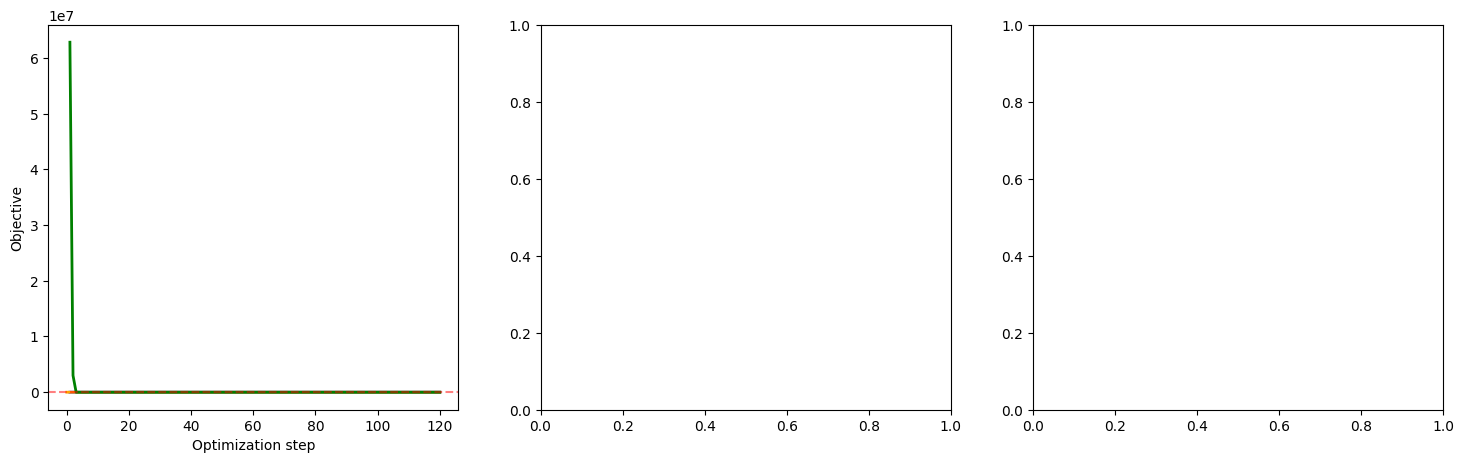

In [24]:
# Experiment 3 visualization: optimization curves overlaid per sample

fig, axes = plt.subplots(1, N_OPT_TEST, figsize=(6 * N_OPT_TEST, 5), squeeze=False)
colors = {'clip [0, 1]': 'blue', 'clip [1e-3, 1]': 'orange', 'binarize (>0.5)': 'green'}

for i in range(N_OPT_TEST):
    ax = axes[0, i]
    ref_obj = None
    for strat_name, res in opt_results[i].items():
        if 'error' in res:
            continue
        ref_obj = res['ref_obj']
        ax.plot(res['obj_history'], label=strat_name, color=colors.get(strat_name, 'gray'), linewidth=2)
    if ref_obj is not None:
        ax.axhline(ref_obj, color='red', ls='--', alpha=0.5, label='Reference optimum')
    ax.set_xlabel('Optimization step')
    ax.set_ylabel('Objective')

    # Build condition string for title
    cond_vals = {k: sampled_conditions[i][k] for k in problem.conditions_keys}
    cond_str = ', '.join(f'{k}={v:.3f}' for k, v in cond_vals.items() if not (isinstance(v, float) and v == 0.0))
    ax.set_title(f'Sample {i}\n{cond_str}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle(f'Optimization Curves Under Different Clipping\n{MODEL_TYPE} / {PROBLEM_ID}', fontsize=13)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Sample':>6} | {'Strategy':>20} | {'IOG':>12} | {'COG':>12} | {'FOG':>12}")
print('-' * 75)
for i in range(N_OPT_TEST):
    for strat_name, res in opt_results[i].items():
        if 'error' in res:
            print(f"{i:>6} | {strat_name:>20} | {'CRASH':>12} | {'CRASH':>12} | {'CRASH':>12}")
        else:
            print(f"{i:>6} | {strat_name:>20} | {res['iog']:>12.4e} | {res['cog']:>12.4e} | {res['fog']:>12.4e}")


## Experiment 6: Per-Sample IOG/COG Distribution

Validate the "mean hides failures" story. Run IOG for more samples and check
if outliers are condition-specific or random.

**Note**: This reuses the default clipping `[0, 1]` from the generation cell.
Each sample requires simulate + optimize, so this takes ~2-5 min per sample.

In [ ]:
# Experiment 6: Per-sample IOG/COG for N samples
N_IOG_TEST = 10  # Increase for more data, ~3 min each

print(f"Problem: {PROBLEM_ID} | Model: {MODEL_TYPE} | Testing {N_IOG_TEST} samples")
print(f"Expected time: ~{N_IOG_TEST * 3} minutes\n")

iog_list = []
cog_list = []
fog_list = []
sample_conditions_list = []

for i in range(N_IOG_TEST):
    design = gen_designs_np[i]  # Already clipped to [0, 1]
    config_i = _numpy_config(sampled_conditions[i])
    w_i = _sample_obj_weights(config_i)

    # Reference objective
    problem.reset(seed=42)
    ref_obj_raw = problem.simulate(design=sampled_designs_np[i], config=config_i)
    ref_val = _scalar_obj(ref_obj_raw, w_i)

    # IOG: simulate generated design
    problem.reset(seed=42)
    gen_obj_raw = problem.simulate(design=design, config=config_i)
    gen_val = _scalar_obj(gen_obj_raw, w_i)
    iog = gen_val - ref_val

    # Optimize
    problem.reset(seed=42)
    _, history = problem.optimize(starting_point=design, config=config_i)
    obj_history = [_scalar_obj(h.obj_values, w_i) for h in history]
    gaps = [v - ref_val for v in obj_history]
    cog = sum(gaps)
    fog = gaps[-1]

    iog_list.append(iog)
    cog_list.append(cog)
    fog_list.append(fog)
    sample_conditions_list.append({k: config_i[k] for k in scalar_cond_keys if k in config_i})

    cond_str = ', '.join(f'{k}={config_i[k]:.3f}' for k in scalar_cond_keys if k in config_i)
    print(f"  Sample {i:>3d}: IOG={iog:>12.4e}, COG={cog:>12.4e}, FOG={fog:>12.4e} | {cond_str[:60]}")

iog_arr = np.array(iog_list)
cog_arr = np.array(cog_list)
fog_arr = np.array(fog_list)

print(f"\n--- Aggregation comparison ---")
print(f"IOG:  mean={iog_arr.mean():.4e},  median={np.median(iog_arr):.4e},  IQR={np.subtract(*np.percentile(iog_arr, [75, 25])):.4e}")
print(f"COG:  mean={cog_arr.mean():.4e},  median={np.median(cog_arr):.4e},  IQR={np.subtract(*np.percentile(cog_arr, [75, 25])):.4e}")
print(f"FOG:  mean={fog_arr.mean():.4e},  median={np.median(fog_arr):.4e},  IQR={np.subtract(*np.percentile(fog_arr, [75, 25])):.4e}")

if iog_arr.max() > 10 * np.median(iog_arr):
    outlier_idx = np.argmax(iog_arr)
    print(f"\n*** OUTLIER DETECTED: Sample {outlier_idx} has IOG={iog_arr[outlier_idx]:.4e} "
          f"({iog_arr[outlier_idx] / np.median(iog_arr):.0f}x median)")
    print(f"    Conditions: {sample_conditions_list[outlier_idx]}")

Problem: heatconduction2d | Model: cgan_cnn_2d | Testing 10 samples
Expected time: ~30 minutes



KeyboardInterrupt: 

In [ ]:
# Experiment 6 visualization: IOG distribution with condition coloring

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Strip plot of IOG values
ax = axes[0]
ax.scatter(range(len(iog_arr)), iog_arr, c='steelblue', s=50, zorder=3)
ax.axhline(iog_arr.mean(), color='red', ls='--', label=f'Mean={iog_arr.mean():.2e}')
ax.axhline(np.median(iog_arr), color='green', ls='--', label=f'Median={np.median(iog_arr):.2e}')
ax.set_xlabel('Sample index')
ax.set_ylabel('IOG')
ax.set_title('Per-sample IOG')
ax.legend()

# IOG vs first condition dimension
ax = axes[1]
first_cond_key = problem.conditions_keys[0]
first_cond_vals = np.array([sc[first_cond_key] for sc in sample_conditions_list])
ax.scatter(first_cond_vals, iog_arr, c='steelblue', s=50)
ax.set_xlabel(first_cond_key)
ax.set_ylabel('IOG')
ax.set_title(f'IOG vs {first_cond_key}')

# COG distribution
ax = axes[2]
ax.scatter(range(len(cog_arr)), cog_arr, c='darkorange', s=50, zorder=3)
ax.axhline(cog_arr.mean(), color='red', ls='--', label=f'Mean={cog_arr.mean():.2e}')
ax.axhline(np.median(cog_arr), color='green', ls='--', label=f'Median={np.median(cog_arr):.2e}')
ax.set_xlabel('Sample index')
ax.set_ylabel('COG')
ax.set_title('Per-sample COG')
ax.legend()

plt.suptitle(f'Per-Sample Metric Distributions\n{MODEL_TYPE} / {PROBLEM_ID} (N={N_IOG_TEST})', fontsize=13)
plt.tight_layout()
plt.show()


## Experiment 7: Constraint-Aware IOG — Is Binarize Cheating?

Binarization showed consistently better IOG, but does it violate the volume fraction constraint?
If `mean(binarized_design) > target_volfrac`, the design uses more material than allowed,
producing artificially better compliance. We need to check whether the IOG advantage survives
when we account for constraint violations.

In [ ]:
# Experiment 7: Compare IOG across clipping strategies WITH volfrac violation tracking
N_CONSTRAINED_TEST = 3  # Samples to test

volfrac_key = None
for key in ['volfrac', 'volume']:
    if key in problem.conditions_keys:
        volfrac_key = key
        break

strategies = {
    "clip [0, 1]": lambda x: np.clip(x, 0.0, 1.0),
    "clip [1e-3, 1]": lambda x: np.clip(x, 1e-3, 1.0),
    "binarize (>0.5)": lambda x: (x > 0.5).astype(float),
}

print(f"Problem: {PROBLEM_ID} | Model: {MODEL_TYPE} | Volfrac key: {volfrac_key}")
print(f"{'Sample':>6} | {'Strategy':>20} | {'IOG':>12} | {'target_vf':>10} | {'actual_vf':>10} | {'vf_error':>10} | {'violated':>8}")
print('-' * 100)

constrained_results = []
for i in range(N_CONSTRAINED_TEST):
    config_i = _numpy_config(sampled_conditions[i])
    w_i = _sample_obj_weights(config_i)
    target_vf = float(config_i[volfrac_key]) if volfrac_key and volfrac_key in config_i else None

    # Reference objective
    problem.reset(seed=42)
    ref_obj_raw = problem.simulate(design=sampled_designs_np[i], config=config_i)
    ref_val = _scalar_obj(ref_obj_raw, w_i)
    ref_vf = sampled_designs_np[i].mean()
    if target_vf is not None:
        print(f"{i:>6} | {'REFERENCE':>20} | {'---':>12} | {target_vf:>10.4f} | {ref_vf:>10.4f} | {ref_vf - target_vf:>+10.4f} |")

    for strat_name, clip_fn in strategies.items():
        design = clip_fn(gen_designs_raw[i])
        actual_vf = design.mean()
        vf_error = actual_vf - target_vf if target_vf is not None else None
        violated = abs(vf_error) >= 0.01 if vf_error is not None else None

        try:
            problem.reset(seed=42)
            obj = problem.simulate(design=design, config=config_i)
            obj_val = _scalar_obj(obj, w_i)
            iog = obj_val - ref_val
        except Exception:
            obj_val, iog = float('nan'), float('nan')

        constrained_results.append({
            'sample': i, 'strategy': strat_name, 'iog': iog,
            'target_vf': target_vf, 'actual_vf': actual_vf,
            'vf_error': vf_error, 'violated': violated,
        })
        if target_vf is not None:
            viol_str = 'YES' if violated else 'no'
            print(f"{i:>6} | {strat_name:>20} | {iog:>12.4e} | {target_vf:>10.4f} | {actual_vf:>10.4f} | {vf_error:>+10.4f} | {viol_str:>8}")
    print()

# Summary: does binarize still win IOG when both are constraint-feasible?
import pandas as pd
df_cr = pd.DataFrame(constrained_results)
print('\n--- IOG comparison (all samples) ---')
print(df_cr.groupby('strategy')['iog'].agg(['mean', 'median']).to_string())
print('\n--- IOG comparison (constraint-feasible only, |vf_error| < 0.01) ---')
feasible = df_cr[df_cr['vf_error'].abs() < 0.01]
if len(feasible) > 0:
    print(feasible.groupby('strategy')['iog'].agg(['mean', 'median', 'count']).to_string())
else:
    print('No feasible samples found!')
print('\n--- Volume fraction error by strategy ---')
print(df_cr.groupby('strategy')['vf_error'].agg(['mean', 'std', 'min', 'max']).to_string())

Problem: heatconduction2d | Model: cgan_cnn_2d | Volfrac key: volume
Sample |             Strategy |          IOG |  target_vf |  actual_vf |   vf_error | violated
----------------------------------------------------------------------------------------------------
     0 |            REFERENCE |          --- |     0.4500 |     0.4513 |    +0.0013 |
     0 |          clip [0, 1] |   6.2612e-05 |     0.4500 |     0.4477 |    -0.0023 |       no
     0 |       clip [1e-3, 1] |   6.2612e-05 |     0.4500 |     0.4479 |    -0.0021 |       no
     0 |      binarize (>0.5) |   7.2018e-05 |     0.4500 |     0.4234 |    -0.0266 |      YES

     1 |            REFERENCE |          --- |     0.4650 |     0.4657 |    +0.0007 |
     1 |          clip [0, 1] |   5.4867e-05 |     0.4650 |     0.4597 |    -0.0053 |       no
     1 |       clip [1e-3, 1] |   5.4867e-05 |     0.4650 |     0.4598 |    -0.0052 |       no
     1 |      binarize (>0.5) |   6.2513e-05 |     0.4650 |     0.4352 |    -0.0298 |  

KeyboardInterrupt: 

## Experiment 8: Simulator & Optimizer Consistency

Are `problem.simulate()` and `problem.optimize()` deterministic across repeated calls?
If there's stochasticity (solver noise, FDFD sensitivity), single-run IOG/COG is unreliable.
We test by running the same design 5 times and checking variance.

For photonics2d especially, the FDFD solver + projection chain may amplify small numerical differences.

In [ ]:
# Experiment 8: Consistency of simulate() and optimize() across repeated runs
N_REPEATS = 3
N_CONSISTENCY_SAMPLES = 3  # Test on 3 different designs

print(f"Problem: {PROBLEM_ID} | Model: {MODEL_TYPE}")
print(f"Running simulate() and optimize() {N_REPEATS} times each on {N_CONSISTENCY_SAMPLES} samples\n")

consistency_results = []

for i in range(N_CONSISTENCY_SAMPLES):
    design = gen_designs_np[i]  # Already clipped
    config_i = _numpy_config(sampled_conditions[i])
    w_i = _sample_obj_weights(config_i)
    cond_str = ', '.join(f'{k}={config_i[k]:.3f}' for k in scalar_cond_keys if k in config_i)
    print(f'--- Sample {i} ({cond_str}) ---')

    # Repeated simulate()
    sim_objs = []
    for r in range(N_REPEATS):
        problem.reset(seed=42)
        obj = problem.simulate(design=design, config=config_i)
        val = _scalar_obj(obj, w_i)
        sim_objs.append(val)

    sim_arr = np.array(sim_objs)
    sim_std = sim_arr.std()
    sim_cv = sim_std / abs(sim_arr.mean()) if sim_arr.mean() != 0 else 0
    print(f'  simulate() x{N_REPEATS}: mean={sim_arr.mean():.6e}, std={sim_std:.6e}, CV={sim_cv:.6e}')
    print(f'    values: {[f"{v:.6e}" for v in sim_objs]}')

    # Repeated optimize()
    opt_finals = []
    opt_cogs = []
    opt_lengths = []
    for r in range(N_REPEATS):
        # Get reference for this repeat
        problem.reset(seed=42)
        ref_obj_raw = problem.simulate(design=sampled_designs_np[i], config=config_i)
        ref_val = _scalar_obj(ref_obj_raw, w_i)

        problem.reset(seed=42)
        _, history = problem.optimize(starting_point=design, config=config_i)
        obj_history = [_scalar_obj(h.obj_values, w_i) for h in history]
        gaps = [v - ref_val for v in obj_history]
        opt_finals.append(obj_history[-1])
        opt_cogs.append(sum(gaps))
        opt_lengths.append(len(obj_history))

    final_arr = np.array(opt_finals)
    cog_arr_local = np.array(opt_cogs)
    final_std = final_arr.std()
    final_cv = final_std / abs(final_arr.mean()) if final_arr.mean() != 0 else 0
    cog_std = cog_arr_local.std()
    cog_cv = cog_std / abs(cog_arr_local.mean()) if cog_arr_local.mean() != 0 else 0
    print(f'  optimize() x{N_REPEATS}:')
    print(f'    final obj:  mean={final_arr.mean():.6e}, std={final_std:.6e}, CV={final_cv:.6e}')
    print(f'    COG:        mean={cog_arr_local.mean():.6e}, std={cog_std:.6e}, CV={cog_cv:.6e}')
    print(f'    n_steps:    {opt_lengths}')
    print(f'    final vals: {[f"{v:.6e}" for v in opt_finals]}')
    print(f'    COG vals:   {[f"{v:.6e}" for v in opt_cogs]}')

    is_deterministic = (final_std < 1e-10 * abs(final_arr.mean() + 1e-30))
    print(f'    Deterministic: {"YES" if is_deterministic else "NO — variance detected!"}')
    print()

    consistency_results.append({
        'sample': i, 'sim_cv': sim_cv, 'final_cv': final_cv, 'cog_cv': cog_cv,
        'sim_std': sim_std, 'final_std': final_std, 'cog_std': cog_std,
    })

print('\n=== Summary ===')
for r in consistency_results:
    print(f"Sample {r['sample']}: sim_CV={r['sim_cv']:.2e}, final_obj_CV={r['final_cv']:.2e}, COG_CV={r['cog_cv']:.2e}")
max_cv = max(r['final_cv'] for r in consistency_results)
if max_cv < 1e-6:
    print(f'\nAll results are deterministic (max CV = {max_cv:.2e}). Single-run metrics are reliable.')
else:
    print(f'\nWARNING: Non-deterministic results detected (max CV = {max_cv:.2e}).')
    print('Consider using best-of-N or median-of-N for robust metrics.')

Problem: heatconduction2d | Model: cgan_cnn_2d
Running simulate() and optimize() 3 times each on 3 samples

--- Sample 0 (volume=0.450, length=0.700) ---
  simulate() x3: mean=9.095834e-05, std=0.000000e+00, CV=0.000000e+00
    values: ['9.095834e-05', '9.095834e-05', '9.095834e-05']


KeyboardInterrupt: 